<h2>Section I. Introduction</h2>

<h3>1.1 Overview</h3>
<p>
This notebook presents a dual-pipeline machine learning project focused on understanding and predicting short-term stock price behavior in the Philippine Stock Exchange (PSE). With over 480,000 daily trading records from 303 publicly listed companies, the analysis explores two perspectives: <strong>non-temporal supervised learning</strong> and <strong>temporal forecasting</strong>. The project aims to extract actionable insights from historical patterns while evaluating the predictive power of both traditional and sequential modeling techniques.
</p>

<h3>1.2 Project Scope and Approach</h3>
<p>
The project is structured around two main tasks. The first focuses on <strong>temporal forecasting</strong>, where models like <code>LSTM</code> and <code>Prophet</code> are applied to capture sequential trends and predict future values of <code>Change%</code>. These models require chronological input and aim to forecast both magnitude and directional shifts using prior market behavior.
</p>

<p>
The second pipeline shifts to a <strong>non-temporal supervised learning pipeline</strong> that treats each stock-day record independently. This setup reframes <code>Change%</code> prediction as a regression task, using models like Random Forest, XGBoost, and others. Time context is ignored in this phase to emphasize row-level pattern recognition through engineered features.
</p>

<p>
Throughout the notebook, the pipeline involves structured phases including data cleaning, feature engineering, normalization, exploratory analysis, model training, evaluation, and visualization. The dual-track setup allows us to compare non-sequential machine learning methods with time-aware models, offering a more holistic understanding of stock price dynamics.
</p>

<h3>1.3 Data Source</h3>
<p>
All stock market data were collected by scraping <a href="https://ph.investing.com" target="_blank">Investing.com</a> using open-source scripts available on GitHub. These scripts can be accessed <a href="https://github.com/ShaneMaglangit/pse-stocks" target="_blank">here</a>. The dataset includes daily trading metrics from December 2011 to March 24, 2021, including open, high, low, close prices, volume, and daily percent change.
</p>

<hr />

<h2>Section II. Dataset Information</h2>

<h3>2.1 Overview and Description</h3>
<p>
The dataset comprises <strong>481,921 daily records</strong> representing trading activity from 303 companies listed on the Philippine Stock Exchange (PSE). Each entry includes core stock market indicators such as opening and closing prices, trading volume, daily high and low, and the percentage change in price from the previous trading day. This data serves as the foundation for both <strong>temporal forecasting</strong> and <strong>non-temporal regression</strong> approaches to predict future values of <code>Change%</code>.
</p>

<ul>
  <li><strong>Records:</strong> 481,921</li>
  <li><strong>Companies:</strong> 303</li>
  <li><strong>Date Range:</strong> December 2011 to March 24, 2021</li>
  <li><strong>Original Features:</strong> 8 input variables</li>
  <li><strong>Target Variable:</strong> <code>Change%</code> – Percentage change in price from the previous day</li>
</ul>

<h3>2.2 Data Collection Process</h3>
<p>
The data was collected via automated web scraping scripts from <a href="https://ph.investing.com" target="_blank">Investing.com</a>, which provides publicly accessible historical stock data. For each company, its individual price history was crawled and compiled into a unified CSV file. The resulting dataset spans nearly a decade of trading activity, covering a wide range of market conditions.
</p>

<p>
The scraping scripts were written in Python and are hosted on GitHub at <a href="https://github.com/ShaneMaglangit/pse-stocks" target="_blank">ShaneMaglangit/pse-stocks</a>.
</p>

<h3>2.3 Structure and Features</h3>
<p>
The cleaned dataset includes the following original columns, with additional engineered features added later to support both supervised regression and time series forecasting tasks:
</p>

<table>
  <thead>
    <tr>
      <th><strong>Feature</strong></th>
      <th><strong>Description</strong></th>
      <th><strong>Data Type</strong></th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>Stock Name</td>
      <td>Full name of the publicly listed company</td>
      <td>String</td>
    </tr>
    <tr>
      <td>Code</td>
      <td>Stock ticker symbol assigned to the company</td>
      <td>String</td>
    </tr>
    <tr>
      <td>Date</td>
      <td>Trading date in YYYY-MM-DD format</td>
      <td>Date</td>
    </tr>
    <tr>
      <td>Open</td>
      <td>Opening price of the stock on the trading day</td>
      <td>Float</td>
    </tr>
    <tr>
      <td>High</td>
      <td>Highest price reached during the trading day</td>
      <td>Float</td>
    </tr>
    <tr>
      <td>Low</td>
      <td>Lowest price reached during the trading day</td>
      <td>Float</td>
    </tr>
    <tr>
      <td>Price</td>
      <td>Closing price at the end of the trading day</td>
      <td>Float</td>
    </tr>
    <tr>
      <td>Volume</td>
      <td>Total number of shares traded that day</td>
      <td>Numeric (K/M/B converted)</td>
    </tr>
    <tr>
      <td>Change%</td>
      <td>Daily percentage change from previous closing price</td>
      <td>Float</td>
    </tr>
  </tbody>
</table>

<p>
Additional engineered features include technical indicators such as moving averages, daily volatility metrics, relative ratios, and lag-based features. These were designed to enrich the feature space for both modeling pipelines: time-aware forecasting using sequential models, and non-temporal regression using tree-based and linear estimators.
</p>

<hr />

<h2>Section III. Data Cleaning and Preprocessing – Forecasting Models</h2>

<p>
Before any meaningful forecasting can be performed, the raw stock data must be cleaned and properly structured to support time series models. At this stage of the pipeline, we focus exclusively on preparing the dataset for sequential models that rely on the correct chronological order of records.
</p>

<p>
The cleaning process ensures that each stock’s price history is sorted by date, complete, and free from structural issues. Key preprocessing steps included parsing date values, handling missing entries, normalizing numerical fields, and engineering basic features required for temporal models. These steps ensure that the data maintains temporal consistency and avoids future information leakage.
</p>

<p>
This structured preparation is critical for models such as <code>LSTM</code> and <code>Prophet</code>, which depend on historical trends to make accurate forward-looking predictions.
</p>


<h3>3.1 Importing Libraries</h3>

In [93]:
# Uncomment the line below if running on Google Colab
# from google.colab import drive

# Core Libraries
import os
import random
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, PowerTransformer

# Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Regression Evaluation Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Classification Evaluation Metrics
from sklearn.metrics import accuracy_score

# Boosting and Feature Importance
import xgboost as xgb
from sklearn.inspection import permutation_importance

# Time Series Forecasting
from prophet import Prophet

# Deep Learning (LSTM)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


In [94]:
# set random seed for reproducibility and consistency
SEED = 42

os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'


<h3>3.2 Loading the Dataset</h3>
<p>
Loading the dataset into a DataFrame for structured access and analysis. Includes basic checks for missing values, data types, and overall structure to prepare for preprocessing and modeling.
</p>


In [95]:
df = pd.read_csv('stocks.csv')
df.head(5)

# sample datafield 100k to reduce computation time, comment below to disable
# df = df.head(100000)

C:\Users\kylei\AppData\Local\Temp\ipykernel_18400\856821776.py:1: DtypeWarning: Columns (3,4,5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('stocks.csv')


,Stock Name,Code,Date,Price,Open,High,Low,Volume,Change%
0,Abra Mining and Industrial Corp,AR,"Mar 03, 2021",0.0046,0.0057,0.0071,0.0043,215.45B,-14.81%
1,Abra Mining and Industrial Corp,AR,"Mar 02, 2021",0.0054,0.0036,0.0054,0.0036,122.74B,50.00%
2,Abra Mining and Industrial Corp,AR,"Mar 01, 2021",0.0036,0.0035,0.0036,0.0033,5.89B,5.88%
3,Abra Mining and Industrial Corp,AR,"Feb 26, 2021",0.0034,0.0033,0.0036,0.0032,9.59B,0.00%
4,Abra Mining and Industrial Corp,AR,"Feb 24, 2021",0.0034,0.0038,0.0038,0.0032,29.68B,-12.82%


<h3>3.3 Checking for Missing Values</h3>

In [96]:
df.replace(['-', '--', 'N/A', 'null', 'NaN', ''], np.nan, inplace=True) 
df.isnull().sum()

Stock Name    0
Code          0
Date          0
Price         0
Open          0
High          0
Low           0
Volume        2
Change%       0
dtype: int64

<p>
At this stage, the dataset is mostly complete, with only two missing values present in the <code>Volume</code> column. All other features are fully populated with no null entries. These missing volume values will be handled after converting the suffixes (e.g., <code>K</code>, <code>M</code>, <code>B</code>) into actual numeric representations during the cleaning process.
</p>

<h3>3.4 Checking for Duplicate Records</h3>
<p>Identifies and removes any duplicate entries to ensure data quality and prevent bias or redundancy during analysis and modeling.</p>

In [97]:
df.duplicated().sum()

np.int64(0)

<p>
No duplicate rows were found in the dataset. This confirms that each record—representing a unique combination of stock code and trading date—is distinct.
</p>

<h3>3.5 Cleaning Numeric and Temporal Features</h3>

<p>
The <code>Date</code> column is converted from string to <code>datetime</code> format to ensure proper chronological handling of records. This transformation enables accurate sorting, time-based indexing, feature engineering (e.g., extracting day, month, year), and is essential for time series modeling components of the pipeline.
</p>

In [98]:
df['Date'] = pd.to_datetime(df['Date'])

<p>
Functions are defined to handle cleaning of numeric and temporal features, including handling of missing values, removing commas, and converting suffixes to numeric values.
</p>

In [99]:
# removes commas, %, and converts to float
def clean_numeric(value):
    if pd.isna(value):
        return np.nan

    value = str(value).strip()
    value = value.replace(',', '').replace('%', '')

    try:
        return float(value)
    except ValueError:
        return np.nan

In [100]:
# converts volume suffix to float
def clean_volume(value):
    if pd.isna(value):
        return np.nan

    value = str(value).strip()
    value = value.replace(',', '')

    if 'B' in value:
        return float(value.replace('B', '')) * 1e9
    elif 'M' in value:
        return float(value.replace('M', '')) * 1e6
    elif 'K' in value:
        return float(value.replace('K', '')) * 1e3
    else:
        return clean_numeric(value)

<p>
Calling the functions to clean the numeric and temporal features.
</p>

In [101]:
df['Volume'] = df['Volume'].apply(clean_volume)
df['Change%'] = df['Change%'].apply(clean_numeric)

<p>
Ordering the data chronologically within each stock. Important for generating features like lagged prices or moving averages.
</p>

In [102]:
df = df.sort_values(['Code', 'Date'])

<p>
Imputing missing values in the <code>Volume</code> column with the median value.
</p>

In [103]:
df['Volume'] = df['Volume'].fillna(df['Volume'].median())

<p>Verifying the missing values</p>

In [104]:
df.isnull().sum()

Stock Name    0
Code          0
Date          0
Price         0
Open          0
High          0
Low           0
Volume        0
Change%       0
dtype: int64

<h3>3.6 Ensuring Correct Numeric Data Types across Columns</h3>
<p>Verifies and enforces appropriate numeric data types to enable accurate computations, transformations, and model training.</p>

In [105]:
numeric_cols = ['Price', 'Open', 'High', 'Low', 'Volume', 'Change%']
for col in numeric_cols:
    df[col] = df[col].astype(str).str.replace(',', '')
    df[col] = pd.to_numeric(df[col], errors='coerce')

<h3>3.7 Feature Engineering</h3>

<p>
Feature engineering for forecasting models involves generating new variables that help capture temporal patterns and market behavior over time. In this pipeline, features are crafted with the assumption that the sequence of records matters—thus enabling the model to learn from historical trends.
</p>

<p>
Key engineered features include future price shifts (e.g., <code>Tomorrow_Change</code>), rolling statistics (e.g., moving averages), and volatility indicators (e.g., <code>Daily_Range</code>). These temporal features are essential for training models like <code>LSTM</code> and <code>Prophet</code>, which rely on sequential input to forecast future values accurately.
</p>

<p>
  <strong>Tomorrow_Price</strong><br>
  This feature shifts the current day's closing price one step forward (within each stock group), aligning each row with the next day's price. 
  It is <em>used solely to create the classification label <code>Price_Up</code></em>. 
  Since it contains future information, <strong>this feature is dropped after label creation to avoid data leakage</strong> and is never used as an input during model training.
</p>

In [106]:
df['Tomorrow_Price'] = df.groupby('Code')['Price'].shift(-1)

<p>
<strong>Price_Up<br></strong> A binary classification feature that indicates whether the price increases on the following day. If tomorrow’s price is higher than today’s, it is labeled as 1; otherwise, it is 0. This helps build a model that predicts short-term upward movements.
</p>

In [107]:
df['Price_Up'] = (df['Tomorrow_Price'] > df['Price']).astype(int)

<p>
<strong>Daily_Range<br></strong> Calculated as the difference between the day’s high and low prices. It serves as a simple volatility measure, indicating how much the stock price moved intraday.
</p>

In [108]:
df['Daily_Range'] = df['High'] - df['Low']

<p><strong>DayOfWeek</strong><br>
Represents the day of the week for each trading record, with values ranging from 0 (Monday) to 4 (Friday). This feature is useful for capturing potential weekly seasonality in stock behavior. For example, some stocks may exhibit end-of-week volatility or early-week corrections, which can provide predictive signals for classification models.
</p>

In [109]:
df['DayOfWeek'] = df['Date'].dt.dayofweek

<p><strong>Volume_Change</strong><br>
A relative measure comparing the current day's trading volume to the stock's 3-day average volume. A value above 1 indicates an increase in trading activity, while a value below 1 suggests reduced volume. Sudden spikes or drops in volume can often precede or confirm significant price movements, making this feature valuable in detecting shifts in trader behavior.
</p>

In [110]:
df['Volume_MA_3'] = df.groupby('Code')['Volume'].transform(lambda x: x.rolling(3).mean())
df['Volume_Change'] = df['Volume'] / df['Volume_MA_3']

<p>
<strong>MA_3<br></strong> 
This feature computes the 3-day moving average of the stock's closing price, grouped by company code. It smooths out short-term fluctuations while remaining responsive to recent price changes. This helps the model capture short-term momentum and provides contextual information about the stock’s recent behavior, which is valuable for predicting immediate price movements.
</p>

In [111]:
df['MA_3'] = df.groupby('Code')['Price'].transform(lambda x: x.rolling(3).mean())

<p><strong>MA_ratio_3_10</strong><br>
This ratio divides the 3-day moving average by the 10-day moving average of the closing price, both computed per stock. It serves as a simple momentum indicator: values greater than 1 suggest upward momentum, while values below 1 may indicate weakening trends. The feature captures the relationship between short-term and medium-term price behavior.
</p>

In [112]:
df['MA_10'] = df.groupby('Code')['Price'].transform(lambda x: x.rolling(10).mean())
df['MA_ratio_3_10'] = df['MA_3'] / df['MA_10']

<p><strong>Lag_Change_1</strong><br>
A lagged version of the daily percentage change in price, shifted by one trading day within each stock group. It provides the model with immediate past performance context, allowing it to learn patterns such as momentum continuation or reversal after a recent price swing.
</p>

In [113]:
df['Lag_Change_1'] = df.groupby('Code')['Change%'].shift(1)

<p>
After feature engineering, several new features (such as moving averages and next-day targets) naturally introduce <code>NaN</code> values. These typically occur at the start or end of each stock’s time series, for example, when there is insufficient historical data for a rolling average, or no next-day value to compare against.
</p>

<p>
Since these rows do not contain complete information required for training or prediction, they are excluded from the dataset. Dropping them ensures that all retained records are valid, fully-featured examples suitable for modeling without introducing bias or noise.
</p>

In [114]:
df = df.dropna().reset_index(drop=True)

<p>
After feature engineering, the columns <code>Tomorrow_Price</code> is dropped, as they are no longer needed for training or prediction.
</p>

In [115]:
df.drop(['Tomorrow_Price'], axis=1, inplace=True)

<strong>Viewing the Dataset After Feature Engineering</strong>

In [116]:
df.head(5)

,Stock Name,Code,Date,Price,Open,High,Low,Volume,Change%,Price_Up,Daily_Range,DayOfWeek,Volume_MA_3,Volume_Change,MA_3,MA_10,MA_ratio_3_10,Lag_Change_1
0,2GO Group Inc,2GO,2012-03-23,3.60,4.10,4.45,3.20,759000.0,-19.10,0,1.25,4,1.419000e+06,0.534884,3.733333,2.336,1.598174,41.27
1,2GO Group Inc,2GO,2012-03-26,3.00,3.20,3.50,3.00,197000.0,-16.67,0,0.50,0,1.232000e+06,0.159903,3.683333,2.501,1.472744,-19.10
2,2GO Group Inc,2GO,2012-03-27,2.83,2.99,3.20,2.51,342000.0,-5.67,1,0.69,1,4.326667e+05,0.790447,3.143333,2.639,1.191108,-16.67
3,2GO Group Inc,2GO,2012-03-28,2.85,3.04,3.05,2.69,365000.0,0.71,1,0.36,2,3.013333e+05,1.211283,2.893333,2.754,1.050593,-5.67
4,2GO Group Inc,2GO,2012-03-29,3.00,2.85,3.20,2.80,374000.0,5.26,0,0.40,3,3.603333e+05,1.037928,2.893333,2.893,1.000115,0.71


<strong>Splitting the Dataset into Training and Testing Sets</strong>

In [117]:
x = df.drop(['Stock Name', 'Code', 'Change%'], axis=1)
y = df['Change%']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=SEED, shuffle=False)


<p>
  The dataset is split into training and testing sets using an 80/20 ratio. 
  The following columns are excluded from the input features:
</p>

<ul>
  <li><strong>Stock Name</strong> – A string identifier for the company, not useful for numerical modeling.</li>
  <li><strong>Code</strong> – The stock ticker symbol, which is also a non-numeric identifier.</li>
  <li><strong>Change%</strong> – The target variable to be predicted; thus, it is removed from the input features.</li>
</ul>

<p>
  These columns are dropped to avoid introducing irrelevant or target-related information into the model training process.
</p>

<strong>Visualizing Outliers</strong>

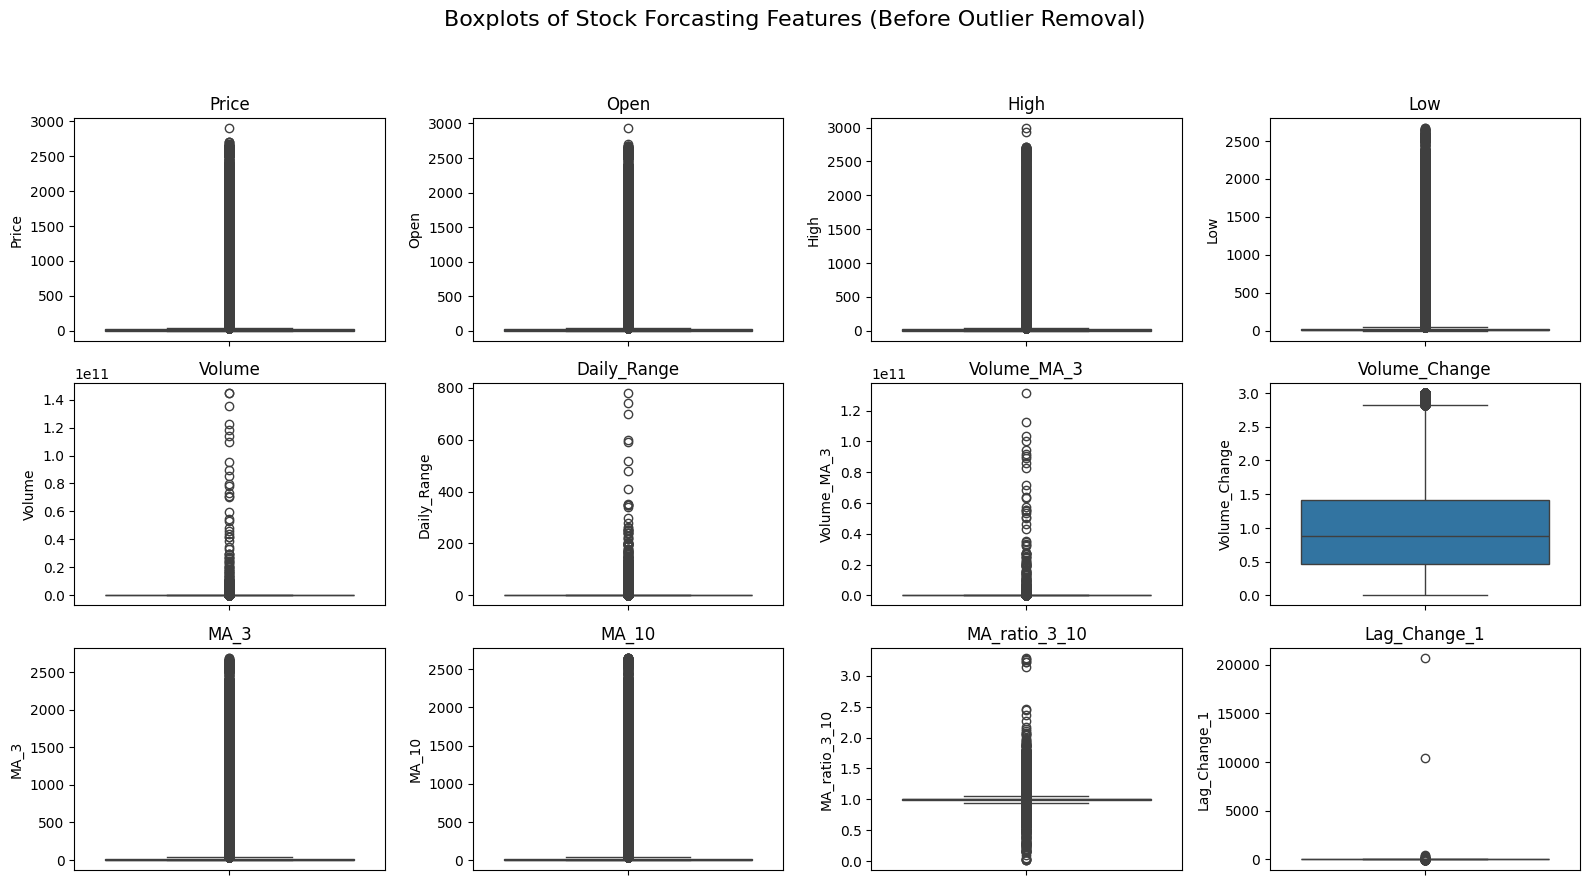

In [118]:
numeric_columns = x_train.select_dtypes(include=['float64', 'int64']).columns.tolist()
numeric_columns.remove('Price_Up')

rows = 4
cols = 4
fig, axes = plt.subplots(rows, cols, figsize=(16, 12))
axes = axes.flatten()

for i, column in enumerate(numeric_columns):
    sns.boxplot(y=x_train[column], ax=axes[i])
    axes[i].set_title(column)
    axes[i].tick_params(axis='x', rotation=90)

for j in range(len(numeric_columns), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Boxplots of Stock Forcasting Features (Before Outlier Removal)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

<strong>Capping Outliers Using the Interquartile Range (IQR)</strong>

In [119]:
# for the features

outlier_columns = list(numeric_columns)

x_train_clipped = x_train.copy()
x_test_clipped = x_test.copy()

for column in outlier_columns:
    Q1 = x_train_clipped[column].quantile(0.25)
    Q3 = x_train_clipped[column].quantile(0.75)

    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    x_train_clipped[column] = x_train_clipped[column].clip(lower_limit, upper_limit)
    x_test_clipped[column] = x_test_clipped[column].clip(lower_limit, upper_limit)

In [120]:
# for the target

Q1 = y_train.quantile(0.25)
Q3 = y_train.quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

y_train = y_train.clip(lower_limit, upper_limit)
y_test = y_test.clip(lower_limit, upper_limit)


<h3>3.8 Outlier Handling</h3>
<p>
Outliers distort the distribution of data, potentially skewing model performance and leading to incorrect predictions.
</p>

<strong >Visualizing Outliers After Clipping</strong>

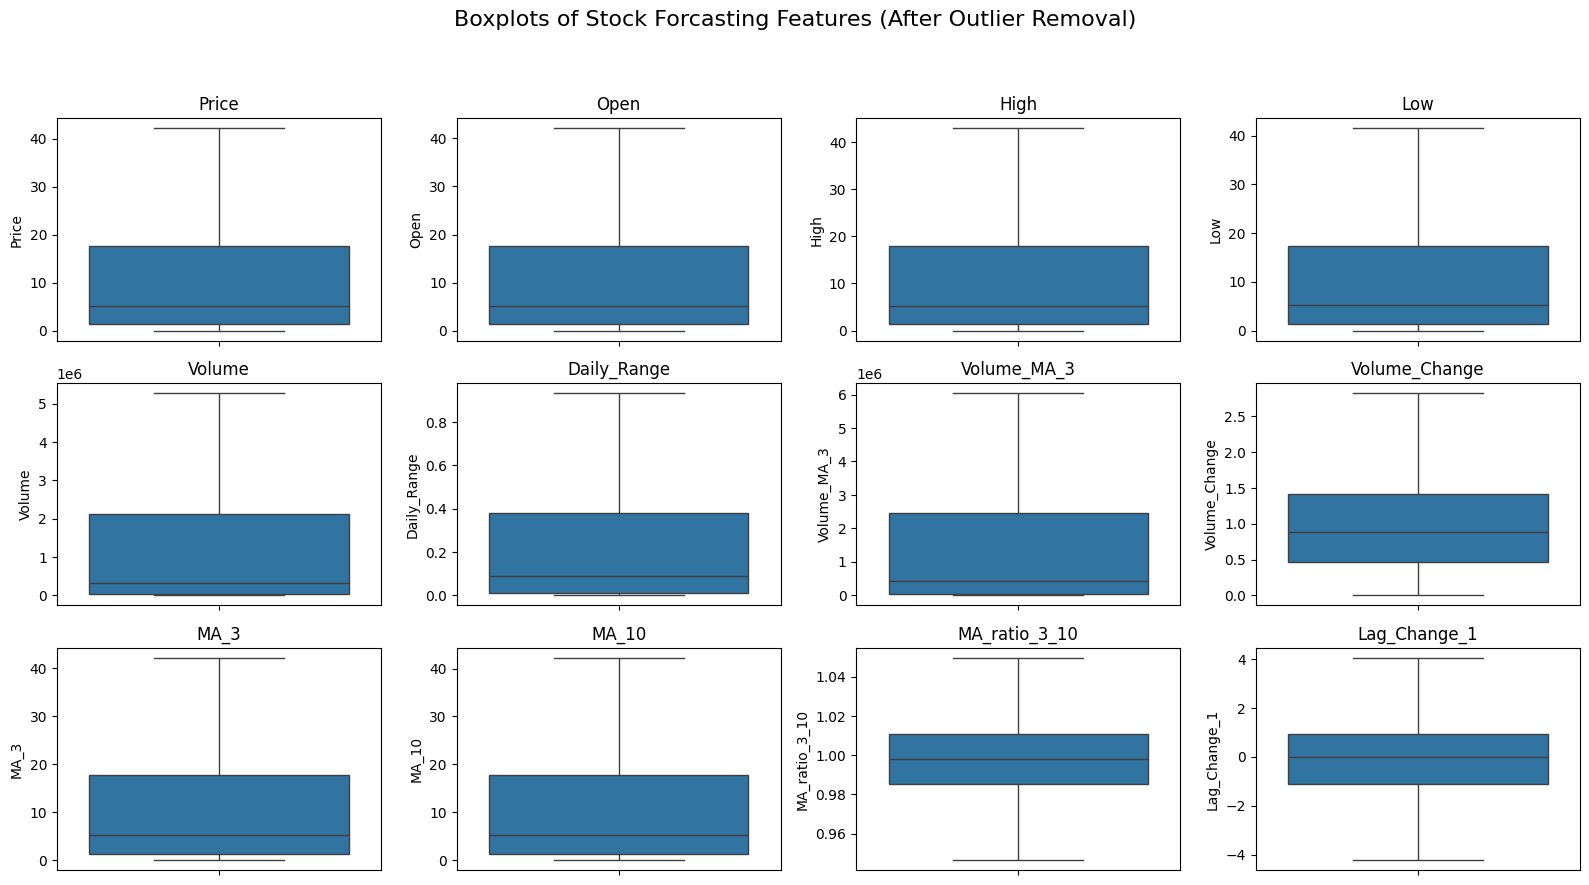

In [121]:
rows = 4
cols = 4
fig, axes = plt.subplots(rows, cols, figsize=(16, 12))
axes = axes.flatten()

for i, column in enumerate(outlier_columns):
    sns.boxplot(y=x_train_clipped[column], ax=axes[i])
    axes[i].set_title(column)
    axes[i].tick_params(axis='x', rotation=90)

for j in range(len(outlier_columns), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Boxplots of Stock Forcasting Features (After Outlier Removal)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

<p>
Boxplots after clipping show reduced presence of extreme values. This confirms that the IQR method effectively limited outliers while preserving the overall distribution of each feature.
</p>

<h3>3.9 Data Transformation</h3>
<p>
To ensure the numerical features are well-suited for modeling, we first check for skewness. A skewness value greater than +1 or less than -1 is considered highly skewed, indicating that the feature distribution is far from normal.
</p>
<p>
Such skewed features can negatively affect models that assume or perform better with normally distributed inputs (e.g., linear models, logistic regression, or models using standardized features).
</p>
<strong>Skewness Check</strong>

In [122]:
x_train_clipped[numeric_columns].skew()

Price            1.134553
Open             1.133143
High             1.137001
Low              1.132913
Volume           1.209112
Daily_Range      1.229704
Volume_MA_3      1.208321
Volume_Change    0.736995
MA_3             1.134104
MA_10            1.134829
MA_ratio_3_10    0.076553
Lag_Change_1     0.027256
dtype: float64

<p>
In the analysis, most of the core features, including <code>Price</code>, <code>Open</code>, <code>High</code>, <code>Low</code>, <code>Volume</code>, <code>Daily_Range</code>, <code>MA_3</code>, and <code>MA_10</code>, all showed skewness values slightly above 1, indicating <strong>moderate to strong right skewness</strong>. These features will benefit from transformation.
</p>

<p>
The feature <code>Daily_Range</code> had the highest skewness at 1.229, further confirming the need for transformation.
</p>

<strong>Yeo-Johnson Transformation</strong>

<p>
Yeo-Johnson transformation is applied to reduce skewness in features. Unlike log or power transforms, it handles both positive and negative values and automatically selects the optimal transformation parameter. This makes it more flexible and suitable for datasets with varied distributions.
</p>

In [123]:
features_to_transform = [
    'Price', 'Open', 'High', 'Low', 'Volume',
    'Daily_Range', 'MA_3', 'Volume_MA_3', 'MA_10'
]

x_train_transformed = x_train_clipped.copy()
x_test_transformed = x_test_clipped.copy()

pt = PowerTransformer(method='yeo-johnson', standardize=False)

x_train_transformed[features_to_transform] = pt.fit_transform(x_train_clipped[features_to_transform])
x_test_transformed[features_to_transform] = pt.transform(x_test_clipped[features_to_transform])

x_train_transformed[features_to_transform].skew()

Price          0.046390
Open           0.046377
High           0.045308
Low            0.047754
Volume        -0.149641
Daily_Range    0.477980
MA_3           0.046304
Volume_MA_3   -0.132447
MA_10          0.046380
dtype: float64

<p>
Skewness values of the transformed features were re-evaluated to confirm the effectiveness of the Yeo-Johnson transformation. All previously skewed features now exhibit skewness values close to 0, indicating an approximately symmetric distribution.
</p>

<h3>3.10 Feature Scaling</h3>
<p>
After addressing skewness and applying any necessary transformations, the next step in the preprocessing pipeline is to scale the features to a common range. Applied <strong>Min-Max normalization</strong> to rescale all numeric features into the range <code>[0, 1]</code>.
</p>

<p>
Min-Max scaling is important because many machine learning algorithms are sensitive to the scale of input features. Without normalization, features with larger numerical ranges may dominate others and negatively impact model performance, especially in distance-based algorithms or neural networks.
</p>

In [124]:
scaler = MinMaxScaler()

x_train_processed = x_train_transformed.copy()
x_test_processed = x_test_transformed.copy()

x_train_processed[numeric_columns] = scaler.fit_transform(x_train_transformed[numeric_columns])
x_test_processed[numeric_columns] = scaler.transform(x_test_transformed[numeric_columns])

<h3>3.11 Validating the Dataset After Preprocessing</h3>

In [125]:
x_train_processed.head()

,Date,Price,Open,High,Low,Volume,Price_Up,Daily_Range,DayOfWeek,Volume_MA_3,Volume_Change,MA_3,MA_10,MA_ratio_3_10,Lag_Change_1
0,2012-03-23,0.446081,0.474313,0.489107,0.423880,0.719034,0,1.000000,4,0.782970,0.189302,0.453686,0.356829,1.000000,1.000000
1,2012-03-26,0.407707,0.421340,0.437385,0.410368,0.563555,0,0.847809,0,0.764055,0.056589,0.450794,0.370353,1.000000,0.000000
2,2012-03-27,0.395685,0.407192,0.418542,0.373876,0.623667,1,0.936477,1,0.634976,0.279751,0.417228,0.381141,1.000000,0.000000
3,2012-03-28,0.397130,0.410633,0.408564,0.387893,0.631067,1,0.739998,2,0.594545,0.428693,0.400036,0.389797,1.000000,0.000000
4,2012-03-29,0.407707,0.397301,0.418542,0.396096,0.633853,0,0.775978,3,0.614276,0.367339,0.400036,0.399881,0.519418,0.596014


<h2>Section IV. Exploratory Data Analysis - Forcasting Models</h2>

<h3>4.1 Correlation Analysis</h3>

<p>
Begin by analyzing the correlation matrix of the preprocessed dataset. This reveals which features are most correlated and how they might impact model performance.
</p>

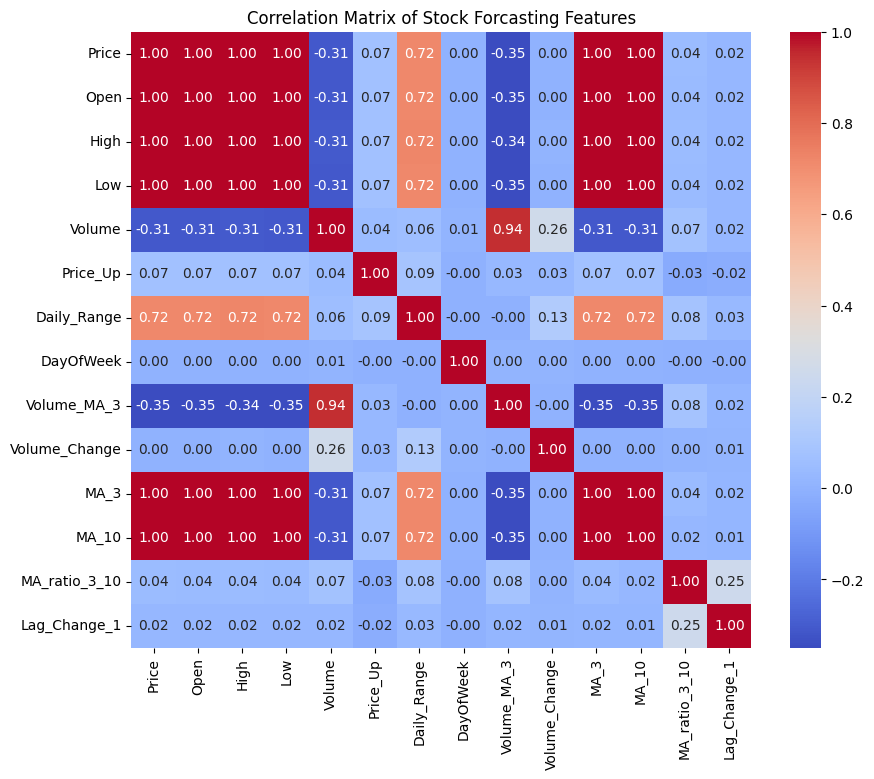

In [126]:
corr_matrix = x_train_processed.select_dtypes(include='number').corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Stock Forcasting Features')
plt.show()

<p>
The heatmap above presents the Pearson correlation matrix for all numerical features. 
Strong positive correlations are shown in red, negative in blue, and near-zero relationships appear pale. 
This visualization helps identify feature redundancy and potential multicollinearity.
</p>

<p>
The features <code>Price</code>, <code>Open</code>, <code>High</code>, and <code>Low</code> are nearly perfectly correlated (ρ ≈ 1.00). 
This is expected, as these represent different aspects of the same stock price movement. 
To reduce redundancy, only the moving average feature <code>MA_3</code> is retained to represent price behavior. 
The rest are removed to avoid multicollinearity.
</p>

<p>
Although <code>MA_3</code> and <code>MA_10</code> are also strongly correlated, both are kept because they reflect different time horizons—
<code>MA_3</code> for short-term movement and <code>MA_10</code> for mid-term trends. 
These features are used to compute <code>MA_ratio_3_10</code>, which captures the momentum between short- and mid-term behavior.
</p>

<p>
High correlation does not automatically justify dropping a feature. 
When two correlated features serve distinct roles or are used in derived metrics, their inclusion may still be beneficial, especially for non-linear models.
</p>


In [127]:
x_train_processed.drop(['High', 'Low', 'Open', 'Price'], axis=1, inplace=True)
x_test_processed.drop(['High', 'Low', 'Open', 'Price'], axis=1, inplace=True)

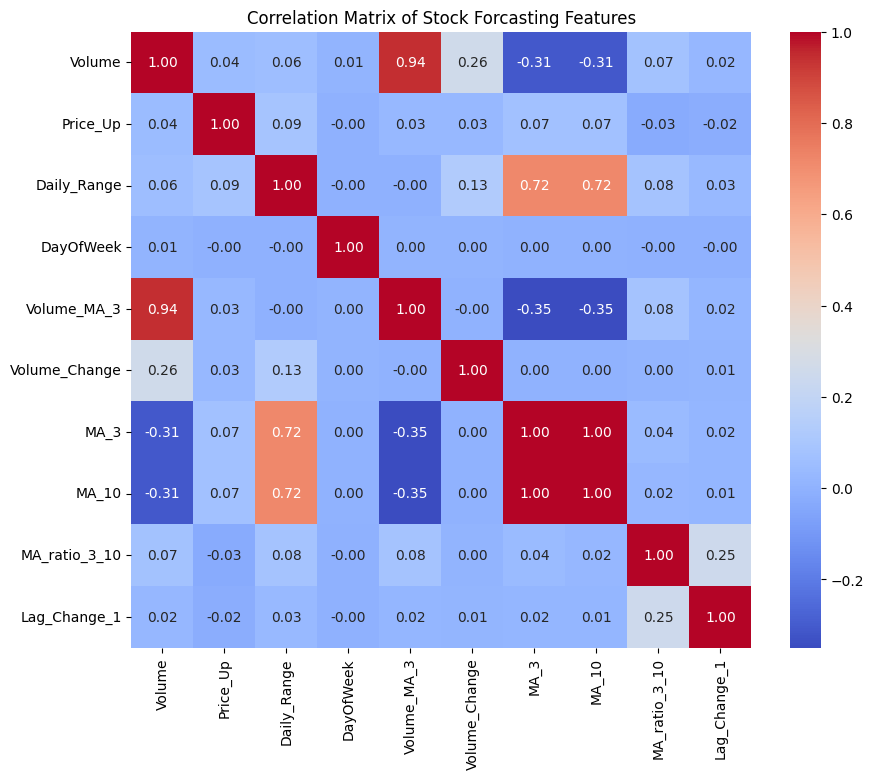

In [128]:
corr_matrix = x_train_processed.select_dtypes(include='number').corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Stock Forcasting Features')
plt.show()

<h4>4.2 Feature Distributions</h4>
<p>
  Analyzing the distributions of each feature helps identify any potential issues or outliers that may affect model performance.
</p>

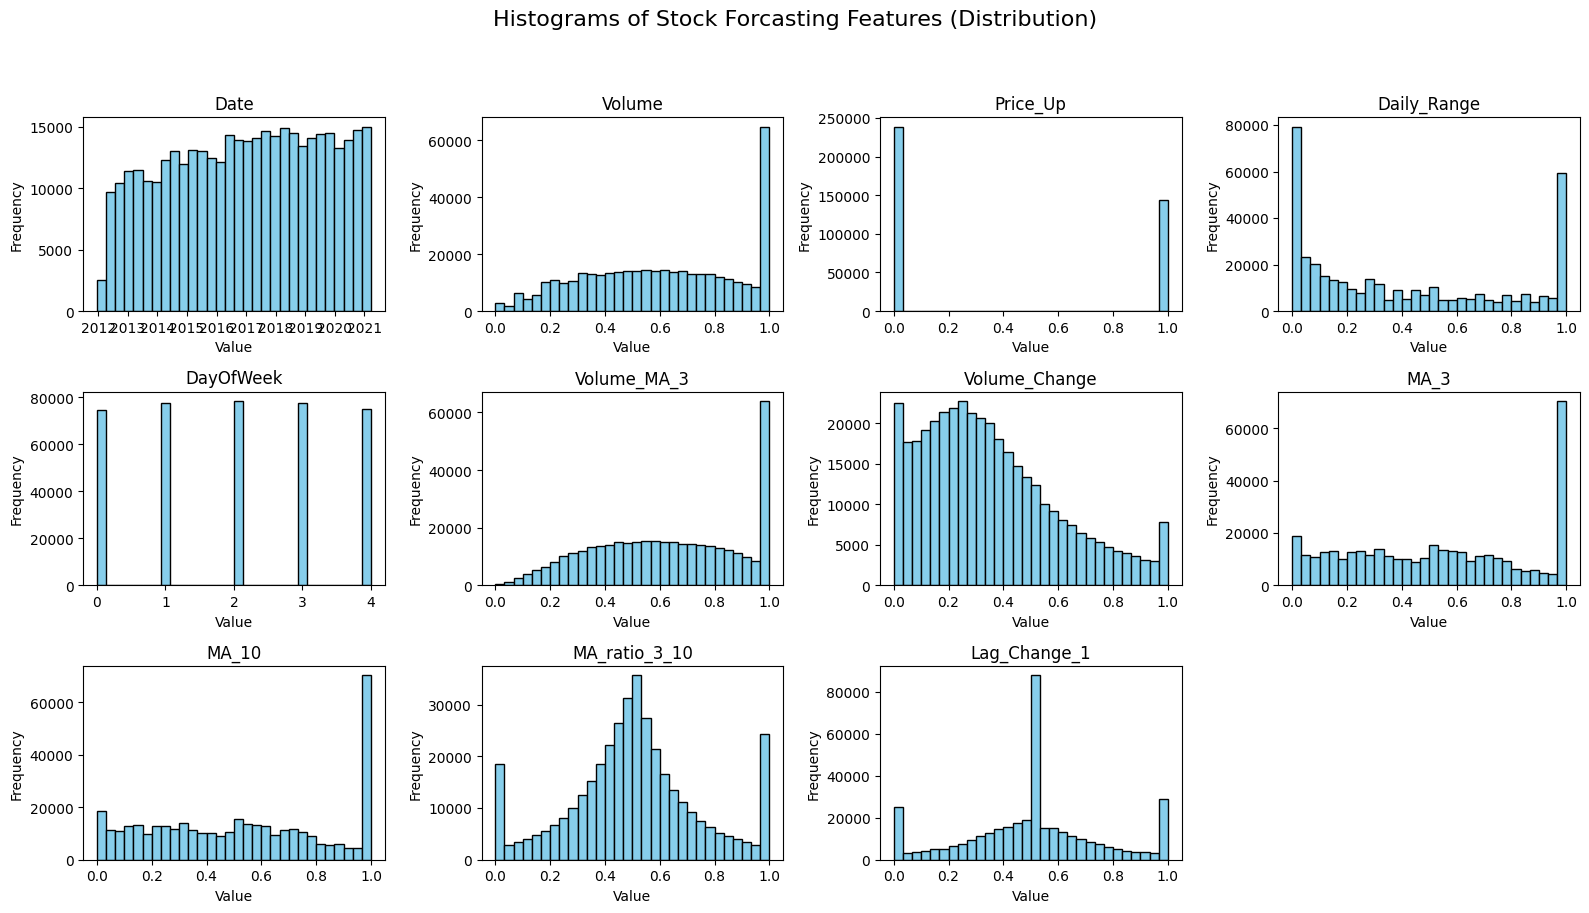

In [129]:
columns = x_train_processed.columns

fig, axes = plt.subplots(rows, cols, figsize=(16, 12))
axes = axes.flatten()

for i, column in enumerate(columns):
    axes[i].hist(x_train_processed[column], bins=30, edgecolor='black', color='skyblue')
    axes[i].set_title(column)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

for j in range(len(columns), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Histograms of Stock Forcasting Features (Distribution)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

<p>
The figures display histograms for twelve engineered and original features, showing the distribution of their values after preprocessing. Most features have been scaled to the range <code>0.0</code> to <code>1.0</code>, and several show clear signs of <strong>capping</strong>—a technique used to limit extreme outlier values.
</p>

<strong>Overall Observations</strong>
<p>
Some features, such as <code>Volume</code>, <code>MA_3</code>, and <code>Daily_Range</code>, exhibit very tall bars at both <code>0.0</code> and <code>1.0</code>, indicating that extreme low and high values were clipped during preprocessing. This confirms that capping was successfully applied, and these boundary values have accumulated or "piled up" at the ends of the scale.
</p>

<p>
In contrast, other features show more natural variation:
</p>
<ul>
  <li><strong><code>Volume_Change</code>:</strong> Displays a slightly right-skewed distribution, where most values are concentrated on the lower end, with a few high-volume shifts capped at <code>1.0</code>.</li>
  <li><strong><code>MA_ratio_3_10</code>:</strong> Shows a roughly Gaussian (bell-shaped) distribution centered near <code>0.5</code>. This indicates a stable relationship between short-term and long-term price trends.</li>
</ul>

<strong>Temporal Features</strong>
<ul>
  <li><strong><code>Date</code>:</strong> The histogram shows a gradual increase in data availability over time, reflecting expanded coverage of more stocks or improved data scraping across the years.</li>
  <li><strong><code>DayOfWeek</code>:</strong> Appears uniformly distributed across five values, corresponding to weekdays. This suggests balanced data collection across trading days, with no observable bias toward specific days of the week.</li>
</ul>

<p>
Overall, the histograms confirm that the preprocessing pipeline effectively normalized the feature space while preserving relevant distribution shapes. Understanding these distributions helps inform both model selection and future feature engineering strategies.
</p>


<h3>4.3 Descriptive Statistics</h3>

In [130]:
x_train_processed.select_dtypes(include='number').describe().T

,count,mean,std,min,25%,50%,75%,max
Volume,383112.0,0.610985,0.280029,0.0,0.386956,0.613736,0.859112,1.0
Price_Up,383112.0,0.376582,0.484529,0.0,0.000000,0.000000,1.000000,1.0
Daily_Range,383112.0,0.400905,0.370686,0.0,0.039050,0.295661,0.758592,1.0
DayOfWeek,383112.0,2.001162,1.402508,0.0,1.000000,2.000000,3.000000,4.0
Volume_MA_3,383112.0,0.628789,0.263914,0.0,0.417399,0.629642,0.859467,1.0
Volume_Change,383112.0,0.353939,0.245192,0.0,0.163944,0.310872,0.498367,1.0
MA_3,383112.0,0.531721,0.324280,0.0,0.250334,0.527147,0.805117,1.0
MA_10,383112.0,0.531747,0.324221,0.0,0.250552,0.527215,0.805265,1.0
MA_ratio_3_10,383112.0,0.504406,0.237608,0.0,0.375000,0.501616,0.625000,1.0
Lag_Change_1,383112.0,0.503076,0.249756,0.0,0.375000,0.510266,0.625000,1.0


<h2>Section V. Initial Model Training - Forcasting Models</h2>

<h3>5.1 Long Short-Term Memory (LSTM)</h3>

<p>
  Long Short-Term Memory (LSTM) is a type of recurrent neural network (RNN) designed to model sequential data by maintaining information across time steps through memory cells and gating mechanisms. Unlike traditional feedforward networks, LSTM is capable of capturing both short-term and long-term dependencies, making it well-suited for tasks involving temporal dynamics.
</p>

<p>
  In the context of stock market prediction, where patterns often depend on historical behavior, LSTM offers a way to learn trends, seasonality, and volatility over time. This model is applied to the chronologically ordered dataset to forecast future price movements based on recent historical patterns encoded in features such as lagged values, moving averages, and volatility measures.
</p>


<h4>Prepare the Data</h4>

In [131]:
lstm_x_train = x_train_processed.drop(["Date"], axis=1)
lstm_x_test = x_test_processed.drop(["Date"], axis=1)

X_train = lstm_x_train.values.reshape((lstm_x_train.shape[0], 1, lstm_x_train.shape[1]))
X_test = lstm_x_test.values.reshape((lstm_x_test.shape[0], 1, lstm_x_test.shape[1]))
y_train_lstm = y_train.values
y_test_lstm = y_test.values

<h4>Build and Train the LSTM Model</h4>

In [132]:
model = Sequential([
    LSTM(64, input_shape=(1, X_train.shape[2])),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.fit(X_train, y_train_lstm, epochs=10, batch_size=64, validation_split=0.1, verbose=1, shuffle=False)

c:\Users\kylei\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
5388/5388 ━━━━━━━━━━━━━━━━━━━━ 33s 5ms/step - loss: 3.9849 - mae: 1.4783 - val_loss: 3.4370 - val_mae: 1.3578
Epoch 2/10
5388/5388 ━━━━━━━━━━━━━━━━━━━━ 28s 5ms/step - loss: 3.7313 - mae: 1.4432 - val_loss: 3.3675 - val_mae: 1.3451
Epoch 3/10
5388/5388 ━━━━━━━━━━━━━━━━━━━━ 28s 5ms/step - loss: 3.6725 - mae: 1.4295 - val_loss: 3.3468 - val_mae: 1.3383
Epoch 4/10
5388/5388 ━━━━━━━━━━━━━━━━━━━━ 28s 5ms/step - loss: 3.6506 - mae: 1.4235 - val_loss: 3.3327 - val_mae: 1.3333
Epoch 5/10
5388/5388 ━━━━━━━━━━━━━━━━━━━━ 28s 5ms/step - loss: 3.6344 - mae: 1.4190 - val_loss: 3.3211 - val_mae: 1.3295
Epoch 6/10
5388/5388 ━━━━━━━━━━━━━━━━━━━━ 29s 5ms/step - loss: 3.6203 - mae: 1.4152 - val_loss: 3.3111 - val_mae: 1.3271
Epoch 7/10
5388/5388 ━━━━━━━━━━━━━━━━━━━━ 31s 6ms/step - loss: 3.6074 - mae: 1.4119 - val_loss: 3.3026 - val_mae: 1.3258
Epoch 8/10
5388/5388 ━━━━━━━━━━━━━━━━━━━━ 31s 6ms/step - loss: 3.5952 - mae: 1.4091 - val_loss: 3.2959 - val_mae: 1.3253
Epoch 9/10
5388/5388 ━━━━━━━━━━━

<h4>Predict and Evaluate</h4>

In [133]:
y_pred = model.predict(X_test).flatten()

lstm_rmse = np.sqrt(mean_squared_error(y_test_lstm, y_pred))
lstm_mae = mean_absolute_error(y_test_lstm, y_pred)
print(f"LSTM RMSE: {lstm_rmse:.4f}")
print(f"LSTM MAE: {lstm_mae:.4f}")

y_test_up = (y_test_lstm > 0).astype(int)
y_pred_up = (y_pred > 0).astype(int)
lstm_directional_acc = accuracy_score(y_test_up, y_pred_up)
print(f"LSTM Directional Accuracy: {lstm_directional_acc:.4f}")

2994/2994 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step
LSTM RMSE: 1.8279
LSTM MAE: 1.3487
LSTM Directional Accuracy: 0.6317


<p>
The LSTM model achieved a <strong>Root Mean Squared Error (RMSE)</strong> of <code>1.8279</code> and a <strong>Mean Absolute Error (MAE)</strong> of <code>1.3487</code> on the test set. Its <strong>Directional Accuracy</strong> was <code>63.17%</code>, indicating that it correctly predicted whether the stock price would go up or down in the next day over 60% of the time.
</p>

<p>
This result demonstrates that the LSTM model was able to learn meaningful temporal patterns in the data. As a sequence-based model, LSTM is particularly well-suited for time series problems like stock prediction. It can retain information from past observations and capture short-term trends or volatility signals that influence next-day price movements.
</p>

<p>
Furthermore, the model benefits from structured feature engineering (e.g., lag features, moving averages), which provides it with contextual information beyond just the raw price or time. This contributes to the model's stronger predictive performance in both continuous value forecasting and directional movement.
</p>

<h3>5.2 Prophet</h3>

<p>
  Prophet is a time series forecasting model developed by Facebook that is designed to handle data with strong trends and seasonality. It works by decomposing a time series into trend, seasonality, and holiday effects, making it suitable for datasets with recurring patterns over time.
</p>

<p>
  Prophet is used to forecast future stock prices based solely on their historical values. Unlike models that rely on engineered features, Prophet uses only the date and price columns, making it a baseline for traditional univariate time series forecasting. This helps provide a point of comparison against more complex models like LSTM.
</p>

<h4>Prepare the Data</h4>

In [134]:
prophet_model = Prophet()

prophet_x_train = pd.DataFrame({'ds': x_train_processed['Date'], 'y': y_train})
prophet_x_test   = pd.DataFrame({'ds': x_test_processed['Date'],  'y': y_test})

<h4>Build and Evaluate</h4>

In [135]:
m = Prophet(daily_seasonality=True, yearly_seasonality=False)
m.fit(prophet_x_train)

future_dates = pd.concat(
    [prophet_x_train[['ds']], prophet_x_test[['ds']]],
    ignore_index=True
).drop_duplicates().sort_values('ds')

forecast = m.predict(future_dates)[['ds', 'yhat']]

merged = prophet_x_test.merge(forecast, on='ds', how='left')
y_true = merged['y'].values
y_pred = merged['yhat'].values

prophet_rmse = np.sqrt(mean_squared_error(y_true, y_pred))
prophet_mae = mean_absolute_error(y_true, y_pred)
prophet_directional_acc = accuracy_score((y_true > 0).astype(int), (y_pred > 0).astype(int))

print(f"Prophet RMSE: {prophet_rmse:.4f}")
print(f"Prophet MAE:  {prophet_mae:.4f}")
print(f"Prophet Directional Accuracy: {prophet_directional_acc:.4f}")

18:57:30 - cmdstanpy - INFO - Chain [1] start processing
19:00:35 - cmdstanpy - INFO - Chain [1] done processing


Prophet RMSE: 1.9806
Prophet MAE:  1.4186
Prophet Directional Accuracy: 0.5859


<p>
The Prophet model yielded a <strong>Root Mean Squared Error (RMSE)</strong> of <code>1.9806</code> and a <strong>Mean Absolute Error (MAE)</strong> of <code>1.4186</code> on the validation set. Its <strong>Directional Accuracy</strong> was only <code>58.59%</code>, indicating that it correctly predicted whether the stock price would increase or decrease less than half the time.
</p>

<p>
These results suggest that while Prophet captured some general patterns in the price trend, it struggled to predict short-term price fluctuations accurately. This is expected, as Prophet is a general-purpose additive time series model that emphasizes long-term trends and seasonal components (e.g., weekly or yearly patterns). It is not optimized for the noisy and highly volatile nature of daily stock price movements, which are influenced by many external and non-seasonal factors such as news, sentiment, or intra-day trading activity.
</p>

<p>
Furthermore, Prophet does not leverage engineered features (like lagged values, technical indicators, or volume changes), which are often crucial for improving predictive accuracy in financial time series. Its reliance on just date and price limits its capacity to adapt to the dynamics of stock market behavior on a day-to-day basis.
</p>

<h3>5.3 XGBoost</h3>
<p>
XGBoost (Extreme Gradient Boosting) is a powerful ensemble learning algorithm based on decision trees. It is widely used in time series and financial forecasting tasks due to its ability to model complex, nonlinear relationships and handle feature interactions effectively. 
</p>

<p>
Compared to LSTM and Prophet, XGBoost benefits from using engineered features such as lag values, moving averages, and volatility indicators, enabling it to capture both short-term patterns and broader trends in historical stock behavior.
</p>

<h4>Initialize XGBoost Model</h4>

In [136]:
xgb_reg = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED
)

<h4>Build and Evaluate</h4>

In [137]:
xgb_x_train = x_train_processed.drop(["Date"], axis=1)
xgb_x_test = x_test_processed.drop(["Date"], axis=1)

xgb_reg.fit(xgb_x_train, y_train)
y_pred = xgb_reg.predict(xgb_x_test)

xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
xgb_mae = mean_absolute_error(y_test, y_pred)

print(f"XGBoost Forecast RMSE: {xgb_rmse:.4f}")
print(f"XGBoost Forecast MAE: {xgb_mae:.4f}")

actual_dir = (y_test > 0).astype(int)
pred_dir = (y_pred > 0).astype(int)

xgb_direction_acc = (actual_dir == pred_dir).mean()

print(f"Directional Accuracy: {xgb_direction_acc:.2%}")

XGBoost Forecast RMSE: 1.8148
XGBoost Forecast MAE: 1.3306
Directional Accuracy: 62.11%


<p>
The XGBoost model produced a <strong>Root Mean Squared Error (RMSE)</strong> of <code>1.8148</code> and a <strong>Mean Absolute Error (MAE)</strong> of <code>1.3306</code> on the test set. It achieved a <strong>Directional Accuracy</strong> of <code>62.11%</code>, correctly predicting the movement direction of the next day’s stock change more than 60% of the time.
</p>

<p>
While the RMSE value is relatively high due to large outliers in predicted magnitude, the directional accuracy indicates that the model was able to consistently identify whether the price would increase or decrease. This suggests that XGBoost is better at capturing general movement patterns than precisely predicting the exact change value.
</p>

<p>
XGBoost, being a tree-based ensemble model, performs well in handling structured data with many engineered features. It can effectively model nonlinear relationships, interactions, and feature importance, making it a strong choice for stock market forecasting when precise sequential memory (like in LSTM) is not required.
</p>

<h3>5.4 Model Performance Comparison</h3>

<h4>Root Mean Squared Error (RMSE) Comparison</h4>

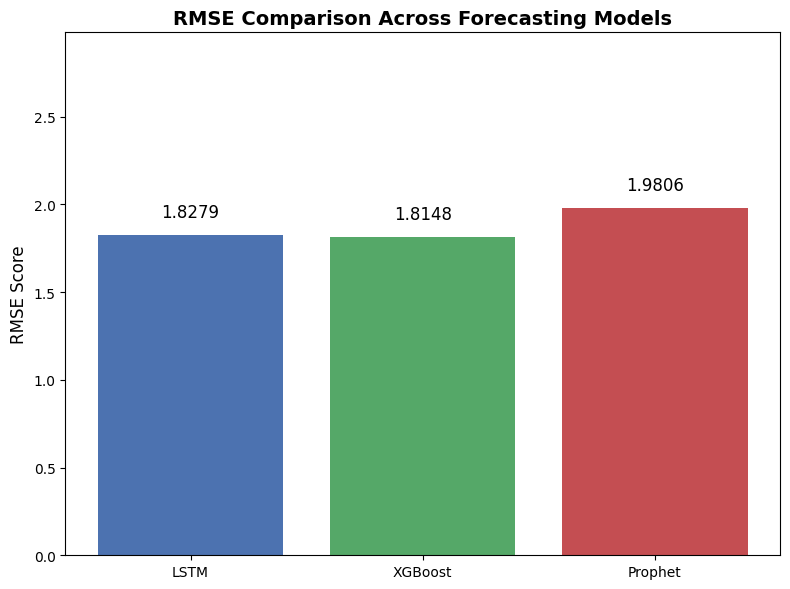

In [138]:
models = ['LSTM', 'XGBoost', 'Prophet']
rmse_scores = [lstm_rmse, xgb_rmse, prophet_rmse]  # Example RMSEs
colors = ['#4C72B0', '#55A868', '#C44E52']

plt.figure(figsize=(8, 6))
bars = plt.bar(models, rmse_scores, color=colors)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.1,
             f'{height:.4f}', ha='center', fontsize=12)

plt.title('RMSE Comparison Across Forecasting Models', fontsize=14, weight='bold')
plt.ylabel('RMSE Score', fontsize=12)
plt.ylim(0, max(rmse_scores) + 1)
plt.tight_layout()
plt.show()


<p>
The graph compares the forecasting performance of three different models—LSTM, XGBoost Forecast, and Prophet—using Root Mean Squared Error (RMSE) as the evaluation metric. A lower RMSE indicates better accuracy in predicting the next day's <code>Change%</code> values.
</p>

<ul>
  <li><strong>XGBoost Forecast:</strong> <code>1.8148</code></li>
  <li><strong>LSTM:</strong> <code>1.8279</code></li>
  <li><strong>Prophet:</strong> <code>1.9806</code></li>
</ul>

<p>
Among the three, the <strong>XGBoost Forecast model achieved the lowest RMSE</strong>, demonstrating the best performance in capturing short-term changes in stock price movement. The LSTM model followed closely, leveraging its strength in handling sequential dependencies in time series data. Prophet, while still effective, showed the highest RMSE among the three, indicating its limitations in adapting to short-term fluctuations despite modeling long-term trends and seasonality.
</p>

<p>
Overall, the results suggest that models equipped to handle sequential structures and engineered features—like XGBoost and LSTM—are better suited for forecasting next-day stock changes than trend-based statistical models like Prophet.
</p>


<h4>Mean Absolute Error (MAE) Comparison</h4>

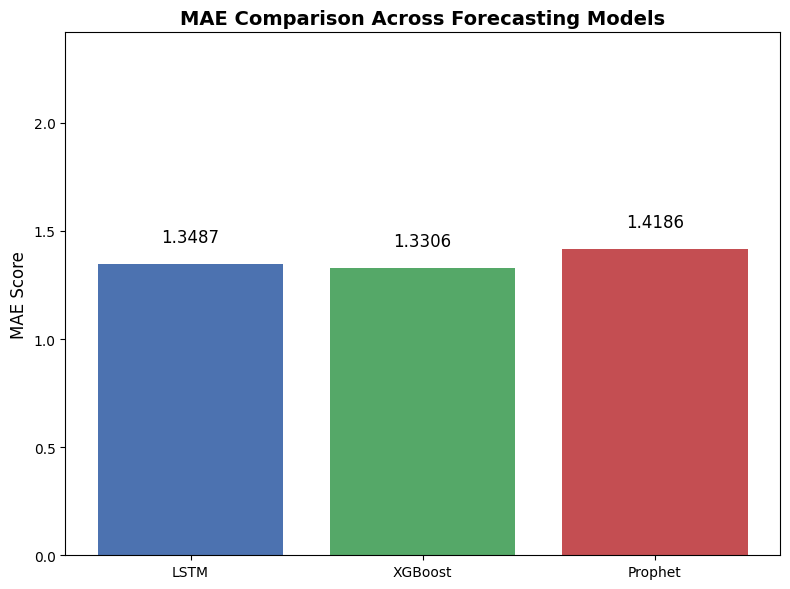

In [139]:
models = ['LSTM', 'XGBoost', 'Prophet']
mae_scores = [lstm_mae, xgb_mae, prophet_mae]
colors = ['#4C72B0', '#55A868', '#C44E52']

plt.figure(figsize=(8, 6))
bars = plt.bar(models, mae_scores, color=colors)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.1,
             f'{height:.4f}', ha='center', fontsize=12)

plt.title('MAE Comparison Across Forecasting Models', fontsize=14, weight='bold')
plt.ylabel('MAE Score', fontsize=12)
plt.ylim(0, max(mae_scores) + 1)
plt.tight_layout()
plt.show()

<p>
The graph presents the Mean Absolute Error (MAE) for the three forecasting models—LSTM, XGBoost Forecast, and Prophet—when predicting the next day’s <code>Change%</code>. MAE measures the average magnitude of prediction errors, with lower values indicating better performance.
</p>

<ul>
  <li><strong>XGBoost Forecast:</strong> <code>1.3306</code></li>
  <li><strong>LSTM:</strong> <code>1.3487</code></li>
  <li><strong>Prophet:</strong> <code>1.4186</code></li>
</ul>

<p>
In terms of MAE, <strong>XGBoost Forecast achieved the best performance</strong>, producing the most consistently accurate predictions on average. The LSTM model followed closely, demonstrating its strength in learning sequential relationships. Prophet, while still effective, had the highest MAE, indicating slightly larger average deviations in its forecasts.
</p>

<p>
These results suggest that <strong>XGBoost provides more stable and precise short-term forecasts</strong>, while LSTM captures temporal patterns effectively. Prophet, although simpler, may be more suited for trend-level forecasting rather than highly dynamic day-to-day changes.
</p>


<h4>Directional Accuracy Comparison</h4>

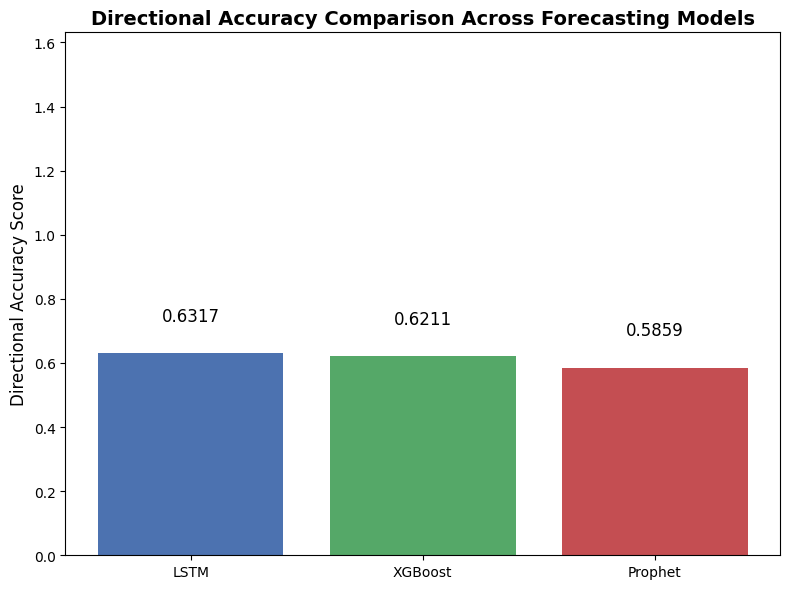

In [140]:
models = ['LSTM', 'XGBoost', 'Prophet']
directional_scores = [lstm_directional_acc, xgb_direction_acc, prophet_directional_acc]
colors = ['#4C72B0', '#55A868', '#C44E52']

plt.figure(figsize=(8, 6))
bars = plt.bar(models, directional_scores, color=colors)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.1,
             f'{height:.4f}', ha='center', fontsize=12)

plt.title('Directional Accuracy Comparison Across Forecasting Models', fontsize=14, weight='bold')
plt.ylabel('Directional Accuracy Score', fontsize=12)
plt.ylim(0, max(directional_scores) + 1)
plt.tight_layout()
plt.show()

<p>
This graph compares the <strong>directional accuracy</strong> of the three forecasting models—LSTM, XGBoost Forecast, and Prophet—on next-day <code>Change%</code> predictions. Directional accuracy measures how often the model correctly predicted the movement direction (positive or negative), regardless of the exact magnitude.
</p>

<ul>
  <li><strong>LSTM:</strong> <code>63.17%</code></li>
  <li><strong>XGBoost Forecast:</strong> <code>62.11%</code></li>
  <li><strong>Prophet:</strong> <code>58.59%</code></li>
</ul>

<p>
Among the models, <strong>LSTM achieved the highest directional accuracy</strong>, successfully capturing the up-or-down movement of stock prices in over 63% of test cases. XGBoost Forecast followed closely at 62.11%, also demonstrating strong consistency in trend detection. Prophet had a slightly lower directional accuracy of 58.59%, reflecting its general capability to model trends but with less precision in capturing short-term market direction.
</p>

<p>
These results suggest that models equipped to handle either sequential dependencies (like LSTM) or engineered input features (like XGBoost) offer improved reliability in forecasting directional shifts—an essential aspect for real-world financial applications such as trading strategy design or risk management.
</p>


<h3>5.5 Summary of Results</h3>

<table>
  <thead>
    <tr>
      <th>Model</th>
      <th>RMSE</th>
      <th>MAE</th>
      <th>Directional Accuracy</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td><strong>LSTM</strong></td>
      <td>1.8279</td>
      <td>1.3487</td>
      <td>63.17%</td>
    </tr>
    <tr>
      <td><strong>XGBoost Forecast</strong></td>
      <td>1.8148</td>
      <td>1.3306</td>
      <td>62.11%</td>
    </tr>
    <tr>
      <td><strong>Prophet</strong></td>
      <td>1.9806</td>
      <td>1.4186</td>
      <td>58.59%</td>
    </tr>
  </tbody>
</table>

<p>
While the RMSE and MAE scores indicate that none of the models achieved perfect accuracy in predicting the exact <code>Change%</code> values for the next day, both <strong>LSTM</strong> and <strong>XGBoost Forecast</strong> demonstrated encouraging results in terms of <strong>directional accuracy</strong>, successfully anticipating the upward or downward movement more than 60% of the time.
</p>

<p>
However, these results should be interpreted with caution. <strong>Stock forecasting remains inherently difficult</strong> due to a number of factors:
</p>

<ul>
  <li>Financial markets are influenced by unpredictable external variables such as news, economic shifts, and investor sentiment—none of which are captured in historical prices alone.</li>
  <li>Short-term price movements are often driven by noise, making them particularly resistant to algorithmic modeling.</li>
  <li>Even sophisticated models like LSTM and XGBoost cannot extract meaningful patterns if the input features lack predictive signal.</li>
</ul>

<p>
In summary, while models like LSTM and XGBoost show some capacity for trend detection, <strong>high-accuracy short-term forecasting remains elusive</strong>. These findings reinforce the broader consensus in finance and machine learning that stock prediction—especially at daily intervals—is constrained by both data limitations and market randomness.
</p>


<hr>

<h2>Section VI. Data Cleaning and Preprocessing – Classification Models</h2>

<p>
This section outlines the preprocessing steps specifically tailored for the classification models used in the non-temporal pipeline. In this setup, each stock-day record is treated as an independent instance, without considering its position in the time sequence. The goal is to enable models to classify patterns based solely on the features present in each row.
</p>

<p>
Unlike forecasting models, classification models like <code>Logistic Regression</code> and <code>Random Forest</code> do not require chronological ordering. Therefore, preprocessing focused on cleaning and standardizing input features, handling missing values, encoding categorical data if necessary, and normalizing numeric fields. Temporal context was deliberately excluded to avoid introducing time-based dependencies.
</p>

<p>
This section closely follows the structure and logic of <strong>Section III: Data Cleaning and Preprocessing – Forecasting Models</strong>, but adapts the steps to suit non-temporal, row-based classification tasks.
</p>

<h3>6.1 Loading the Dataset</h3>


In [141]:
df = pd.read_csv('stocks.csv')
df.head(5)

# sample datafield 100k to reduce computation time, comment below to disable
# df = df.head(100000)

C:\Users\kylei\AppData\Local\Temp\ipykernel_18400\856821776.py:1: DtypeWarning: Columns (3,4,5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('stocks.csv')


,Stock Name,Code,Date,Price,Open,High,Low,Volume,Change%
0,Abra Mining and Industrial Corp,AR,"Mar 03, 2021",0.0046,0.0057,0.0071,0.0043,215.45B,-14.81%
1,Abra Mining and Industrial Corp,AR,"Mar 02, 2021",0.0054,0.0036,0.0054,0.0036,122.74B,50.00%
2,Abra Mining and Industrial Corp,AR,"Mar 01, 2021",0.0036,0.0035,0.0036,0.0033,5.89B,5.88%
3,Abra Mining and Industrial Corp,AR,"Feb 26, 2021",0.0034,0.0033,0.0036,0.0032,9.59B,0.00%
4,Abra Mining and Industrial Corp,AR,"Feb 24, 2021",0.0034,0.0038,0.0038,0.0032,29.68B,-12.82%


<h3>6.2 Checking for Missing Values</h3>

In [142]:
df.replace(['-', '--', 'N/A', 'null', 'NaN', ''], np.nan, inplace=True) 
df.isnull().sum()

Stock Name    0
Code          0
Date          0
Price         0
Open          0
High          0
Low           0
Volume        2
Change%       0
dtype: int64

<p>
At this stage, the dataset is mostly complete, with only two missing values present in the <code>Volume</code> column. All other features are fully populated with no null entries. These missing volume values will be handled after converting the suffixes (e.g., <code>K</code>, <code>M</code>, <code>B</code>) into actual numeric representations during the cleaning process.
</p>

<h3>6.3 Checking for Duplicate Records</h3>


In [143]:
df.duplicated().sum()

np.int64(0)

<p>
No duplicate rows were found in the dataset. This confirms that each record—representing a unique combination of stock code and trading date—is distinct.
</p>

<h3>6.4 Cleaning Numeric Features</h3>

<p>
Functions are defined to handle cleaning of numeric features, including handling of missing values, removing commas, and converting suffixes to numeric values.
</p>

In [144]:
# removes commas, %, and converts to float
def clean_numeric(value):
    if pd.isna(value):
        return np.nan

    value = str(value).strip()
    value = value.replace(',', '').replace('%', '')

    try:
        return float(value)
    except ValueError:
        return np.nan

In [145]:
# converts volume suffix to float
def clean_volume(value):
    if pd.isna(value):
        return np.nan

    value = str(value).strip()
    value = value.replace(',', '')

    if 'B' in value:
        return float(value.replace('B', '')) * 1e9
    elif 'M' in value:
        return float(value.replace('M', '')) * 1e6
    elif 'K' in value:
        return float(value.replace('K', '')) * 1e3
    else:
        return clean_numeric(value)

<p>
Calling the functions to clean the numeric features.
</p>

In [146]:
df['Volume'] = df['Volume'].apply(clean_volume)
df['Change%'] = df['Change%'].apply(clean_numeric)

<p>
Imputing missing values in the <code>Volume</code> column with the median value.
</p>

In [147]:
df['Volume'] = df['Volume'].fillna(df['Volume'].median())

<p>Verifying the missing values</p>

In [148]:
df.isnull().sum()

Stock Name    0
Code          0
Date          0
Price         0
Open          0
High          0
Low           0
Volume        0
Change%       0
dtype: int64

<h3>6.5 Ensuring Correct Numeric Data Types across Columns</h3>
<p>Verifies and enforces appropriate numeric data types to enable accurate computations, transformations, and model training.</p>

In [149]:
numeric_cols = ['Price', 'Open', 'High', 'Low', 'Volume', 'Change%']
for col in numeric_cols:
    df[col] = df[col].astype(str).str.replace(',', '')
    df[col] = pd.to_numeric(df[col], errors='coerce')

<h3>6.6 Feature Engineering</h3>

<p>
Feature engineering for the classification pipeline focuses on constructing informative, row-level features while deliberately avoiding any time-based dependencies. Each record is treated as an independent snapshot of a stock’s trading day, allowing the model to predict outcomes like next-day <code>Change%</code> based solely on present-day indicators.
</p>

<p>
Unlike temporal models that rely on sequences or historical trends, this non-temporal setup assumes that patterns within a single trading day are sufficient to infer likely movements. Therefore, all features are derived from the same row, using only the available values from that specific day.
</p>

<p>
This approach supports general-purpose models like Logistic Regression, Random Forest, and XGBoost, allowing them to recognize statistical patterns within isolated records—making the classification pipeline scalable, flexible, and compatible with tabular machine learning workflows.
</p>


<strong>Tomorrow_Change</strong><br>
<p>
This target feature is engineered by shifting the current day's <code>Change%</code> forward by one step within each stock group. 
This means that each row is aligned with the <em>next day's</em> percentage change, making it suitable for predicting future movement based on <strong>today’s</strong> observable features.
</p>

<p>
While <code>Change%</code> is inherently temporal (since it measures daily price movement), we treat <code>Tomorrow_Change</code> as a <strong>predictive label</strong> and remove any temporal context from the input features.
This allows us to build a non-temporal model where each row is considered independent, using only current-day data to estimate tomorrow’s return.
</p>

In [150]:
df = df.sort_values(by=["Code", "Date"])
df["Tomorrow_Change"] = df.groupby("Code")["Change%"].shift(-1)

<p>
  <strong>Daily_Range</strong><br>
  This feature represents the price volatility within a single trading day. 
  It is calculated as the difference between the highest and lowest prices of the day.
  A larger range indicates more intraday price movement, which may be associated with market uncertainty or momentum.
</p>


In [151]:
df['Daily_Range'] = df['High'] - df['Low']

<p>
  <strong>Price_Position</strong><br>
  This feature determines where the closing price lies within the day's high-low range. 
  The value is scaled between 0 and 1, where 0 means the price closed at the low, and 1 means it closed at the high. 
  It captures intraday sentiment, a close near the high may suggest bullish momentum.
</p>


In [152]:
df['Price_Position'] = (df['Price'] - df['Low']) / (df['High'] - df['Low'] + 1e-9)


<p>
  <strong>Relative_Change_Open</strong><br>
  This feature calculates the percentage change from the opening price to the closing price. 
  It helps measure the gain or loss within a trading day and can provide signals about buyer/seller pressure.
</p>

In [153]:
df['Relative_Change_Open'] = (df['Price'] - df['Open']) / df['Open']


<p>
  <strong>Body_Size</strong><br>
  This feature captures the absolute difference between the opening and closing prices. 
  It reflects the size of the real body of a candlestick, where larger values imply stronger directional movement during the day.
</p>


In [154]:
df['Body_Size'] = abs(df['Price'] - df['Open'])


<p>
  <strong>Upper_Shadow</strong><br>
  This feature measures the distance from the higher of the open or close to the day's high. 
  It represents price rejection at higher levels. 
  A longer upper shadow may suggest selling pressure near the top.
</p>


In [155]:
df['Upper_Shadow'] = df['High'] - df[['Open', 'Price']].max(axis=1)


<p>
  <strong>Lower_Shadow</strong><br>
  This feature calculates the distance from the lower of the open or close to the day's low. 
  It highlights price rejection at lower levels. 
  A longer lower shadow can indicate buying pressure or support.
</p>


In [156]:
df['Lower_Shadow'] = df[['Open', 'Price']].min(axis=1) - df['Low']


<p>
  <strong>Volume_to_Price</strong><br>
  This feature divides the trading volume by the closing price to normalize volume across stocks with different price levels. 
  It acts as a proxy for relative trading activity.
</p>


In [157]:
df['Volume_to_Price'] = df['Volume'] / (df['Price'] + 1e-9)


<p>
  <strong>Price_Range_Ratio</strong><br>
  This feature measures the daily price movement (high - low) relative to the opening price. 
  It provides a volatility metric that accounts for the price scale of the stock.
</p>


In [158]:
df['Price_Range_Ratio'] = (df['High'] - df['Low']) / (df['Open'] + 1e-9)


<p>
During the feature engineering process, a few <code>NaN</code> values were introduced. This is expected when creating features that involve shifting values within groups or performing arithmetic operations that may involve division by zero.
</p>

<p>
To ensure the model is trained only on valid, fully-defined records, we removed all rows with missing values in any of the engineered features.
</p>

In [159]:
df.dropna(inplace=True)

<strong>Viewing the Dataset After Feature Engineering</strong>

In [160]:
df.head(5)

,Stock Name,Code,Date,Price,Open,High,Low,Volume,Change%,Tomorrow_Change,Daily_Range,Price_Position,Relative_Change_Open,Body_Size,Upper_Shadow,Lower_Shadow,Volume_to_Price,Price_Range_Ratio
245056,2GO Group Inc,2GO,"Apr 01, 2013",1.68,1.68,1.68,1.68,6000.0,0.60,1.20,0.00,0.000000,0.000000,0.00,0.00,0.0,3571.428569,0.000000
244888,2GO Group Inc,2GO,"Apr 01, 2014",2.54,2.51,2.54,2.51,12000.0,1.20,0.00,0.03,1.000000,0.011952,0.03,0.00,0.0,4724.409447,0.011952
244656,2GO Group Inc,2GO,"Apr 01, 2015",7.00,7.04,7.48,6.90,1120000.0,0.00,-0.13,0.58,0.172414,-0.005682,0.04,0.44,0.1,159999.999977,0.082386
244415,2GO Group Inc,2GO,"Apr 01, 2016",7.42,7.43,7.50,7.42,90000.0,-0.13,2.46,0.08,0.000000,-0.001346,0.01,0.07,0.0,12129.380052,0.010767
243683,2GO Group Inc,2GO,"Apr 01, 2019",12.50,12.30,12.50,12.20,20100.0,2.46,1.50,0.30,1.000000,0.016260,0.20,0.00,0.1,1608.000000,0.024390


<strong>Splitting the Dataset into Training and Testing Sets</strong>

In [161]:
x = df.drop(['Tomorrow_Change', 'Change%', 'Date', 'Stock Name', 'Code'], axis=1)
y = df['Tomorrow_Change']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=SEED, shuffle=True)

<p>
  Similar to the temporal pipeline, the dataset is split into training and testing sets using an 80/20 ratio. 
  The following columns are excluded from the input features:
</p>

<ul>
  <li><strong>Stock Name</strong> – A string identifier for the company, not meaningful for numerical prediction.</li>
  <li><strong>Code</strong> – The stock ticker symbol, which serves as a non-numeric identifier.</li>
  <li><strong>Change%</strong> – Shifted by -1 to align with the target variable; excluded to avoid data leakage.</li>
  <li><strong>Date</strong> – Removed since temporal context is not considered in this pipeline.</li>
  <li><strong>Tomorrow_Change</strong> – The target variable to be predicted.</li>
</ul>

<p>
  These exclusions help ensure that the model trains only on relevant and non-leaking features.
</p>

<h3>6.7 Handling Outliers</h3>

<strong>Visualizing Outliers</strong>

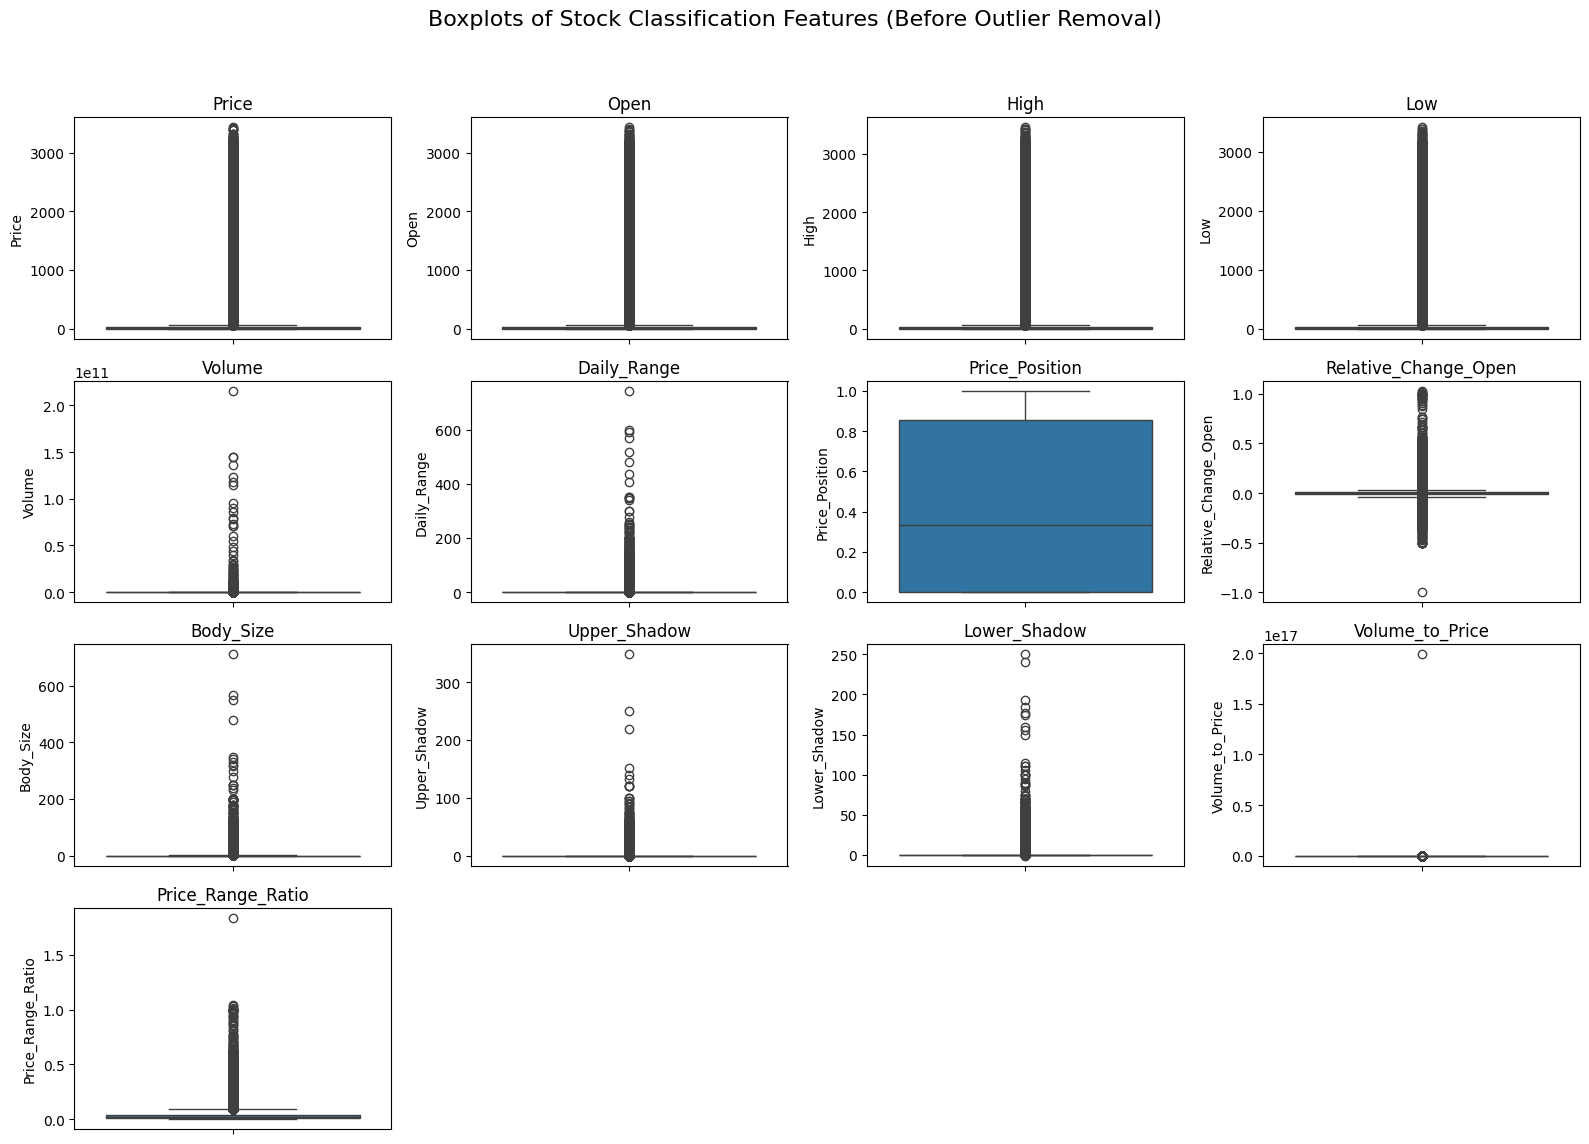

In [162]:
numeric_columns = x_train.select_dtypes(include=['float64', 'int64']).columns.tolist()

rows = 4
cols = 4
fig, axes = plt.subplots(rows, cols, figsize=(16, 12))
axes = axes.flatten()

for i, column in enumerate(numeric_columns):
    sns.boxplot(y=x_train[column], ax=axes[i])
    axes[i].set_title(column)
    axes[i].tick_params(axis='x', rotation=90)

for j in range(len(numeric_columns), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Boxplots of Stock Classification Features (Before Outlier Removal)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

<strong>Capping Outliers Using the Interquartile Range (IQR)</strong>

In [163]:
# for the features

outlier_columns = list(numeric_columns)
outlier_columns.remove('Price_Position') #doesnt contain outliers

x_train_clipped = x_train.copy()
x_test_clipped = x_test.copy()

for column in outlier_columns:
    Q1 = x_train_clipped[column].quantile(0.25)
    Q3 = x_train_clipped[column].quantile(0.75)

    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    x_train_clipped[column] = x_train_clipped[column].clip(lower_limit, upper_limit)
    x_test_clipped[column] = x_test_clipped[column].clip(lower_limit, upper_limit)

In [164]:
# for the target

Q1 = y_train.quantile(0.25)
Q3 = y_train.quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

y_train = y_train.clip(lower_limit, upper_limit)
y_test = y_test.clip(lower_limit, upper_limit)

<strong >Visualizing Outliers After Clipping</strong>

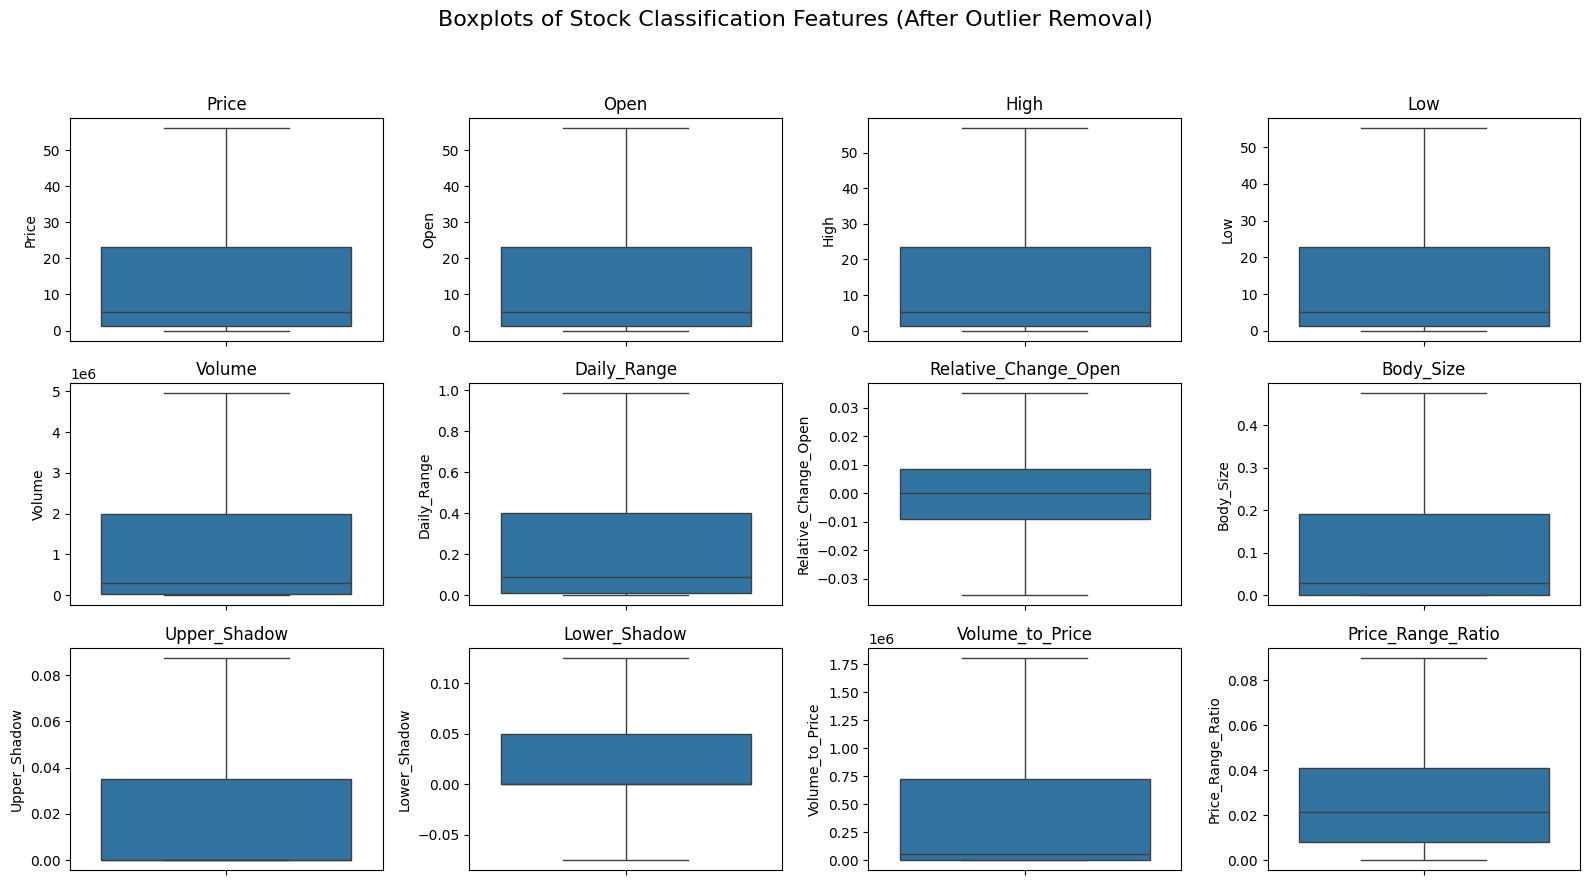

In [165]:
rows = 4
cols = 4
fig, axes = plt.subplots(rows, cols, figsize=(16, 12))
axes = axes.flatten()

for i, column in enumerate(outlier_columns):
    sns.boxplot(y=x_train_clipped[column], ax=axes[i])
    axes[i].set_title(column)
    axes[i].tick_params(axis='x', rotation=90)

for j in range(len(outlier_columns), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Boxplots of Stock Classification Features (After Outlier Removal)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

<h3>6.8 Data Transformation</h3>
<p>
To prepare the features for modeling in the non-temporal pipeline, skewness is examined to assess distribution normality. 
A skewness value greater than +1 or less than -1 is considered highly skewed, indicating a significant deviation from normal distribution.
</p>
<p>
Such skewness can adversely affect models that assume or perform better with approximately normal input distributions, 
such as linear models, logistic regression, or models that rely on standardized features.
</p>
<strong>Skewness Check</strong>


In [166]:
x_train_clipped[numeric_columns].skew()

Price                   1.158912
Open                    1.158484
High                    1.159548
Low                     1.157807
Volume                  1.209018
Daily_Range             1.199631
Price_Position          0.282639
Relative_Change_Open    0.068781
Body_Size               1.238746
Upper_Shadow            1.225603
Lower_Shadow            1.272864
Volume_to_Price         1.191145
Price_Range_Ratio       0.997179
dtype: float64

<p>
In the non-temporal pipeline, several numerical features—including <code>Price</code>, <code>Open</code>, <code>High</code>, <code>Low</code>, <code>Volume</code>, <code>Daily_Range</code>, <code>Body_Size</code>, <code>Upper_Shadow</code>, <code>Lower_Shadow</code>, and <code>Volume_to_Price</code>—exhibited <strong>moderate to strong right skewness</strong>, with skewness values exceeding +1. These features are candidates for transformation to improve model performance.
</p>

<strong>Yeo-Johnson Transformation</strong>

<p>
To reduce skewness among the selected features, the Yeo-Johnson transformation is applied. Unlike traditional transformations such as log or power transforms, Yeo-Johnson can handle both positive and negative values, making it well-suited for datasets with diverse distributions. It also automatically determines the optimal transformation parameter for each feature, offering greater flexibility and stability in preprocessing.
</p>


In [167]:
features_to_transform = [
    'Price', 'Open', 'High', 'Low', 'Volume',
    'Daily_Range', 'Body_Size', 'Upper_Shadow', 'Lower_Shadow', 'Volume_to_Price'
]

x_train_transformed = x_train_clipped.copy()
x_test_transformed = x_test_clipped.copy()

pt = PowerTransformer(method='yeo-johnson', standardize=False)

x_train_transformed[features_to_transform] = pt.fit_transform(x_train_clipped[features_to_transform])
x_test_transformed[features_to_transform] = pt.transform(x_test_clipped[features_to_transform])

x_train_transformed[features_to_transform].skew()

Price              0.079812
Open               0.079933
High               0.078332
Low                0.081387
Volume            -0.150453
Daily_Range        0.493910
Body_Size          0.603232
Upper_Shadow       0.809537
Lower_Shadow       0.762436
Volume_to_Price   -0.158605
dtype: float64

<p>
Skewness values of the transformed features were re-evaluated to assess the effectiveness of the Yeo-Johnson transformation. All previously skewed features now exhibit skewness values close to 0, indicating a more symmetric distribution. This confirms the transformation's effectiveness in normalizing feature distributions, making them more suitable for modeling.
</p>


<h3>6.9 Feature Scaling</h3>
<p>
Following skewness correction and transformation, feature scaling is applied to standardize the numeric input values. <strong>Min-Max normalization</strong> is used to rescale all numerical features into the range <code>[0, 1]</code>. This ensures that all features contribute equally during model training, particularly for algorithms sensitive to feature scale.
</p>


In [168]:
scaler = MinMaxScaler()

x_train_processed = x_train_transformed.copy()
x_test_processed = x_test_transformed.copy()

x_train_processed[numeric_columns] = scaler.fit_transform(x_train_transformed[numeric_columns])
x_test_processed[numeric_columns] = scaler.transform(x_test_transformed[numeric_columns])

<h3>6.10 Validating the Dataset After Preprocessing</h3>

In [169]:
x_train_processed.head()

,Price,Open,High,Low,Volume,Daily_Range,Price_Position,Relative_Change_Open,Body_Size,Upper_Shadow,Lower_Shadow,Volume_to_Price,Price_Range_Ratio
465435,1.000000,1.000000,1.000000,1.000000,0.065240,0.000000,0.000000,0.504914,0.000000,0.000000,0.874090,0.003034,0.000000
296077,0.439513,0.438948,0.439930,0.435021,0.615966,0.464082,0.705882,0.544784,0.072598,0.878241,0.997615,0.647357,0.534700
228977,0.327056,0.331601,0.331396,0.328194,1.000000,0.259093,0.125000,0.159962,0.311770,0.549224,0.905044,1.000000,0.435407
393793,0.558199,0.561492,0.560273,0.557848,1.000000,0.580862,0.400000,0.292007,0.509680,0.865874,0.994407,0.894905,0.419901
260427,0.144428,0.151762,0.152554,0.143541,0.887503,0.202404,0.166667,0.000000,0.258793,0.326601,0.905044,1.000000,1.000000


<h2>Section VII. Exploratory Data Analysis - Classification Models</h2>

<h3>7.1 Correlation Analysis</h3>

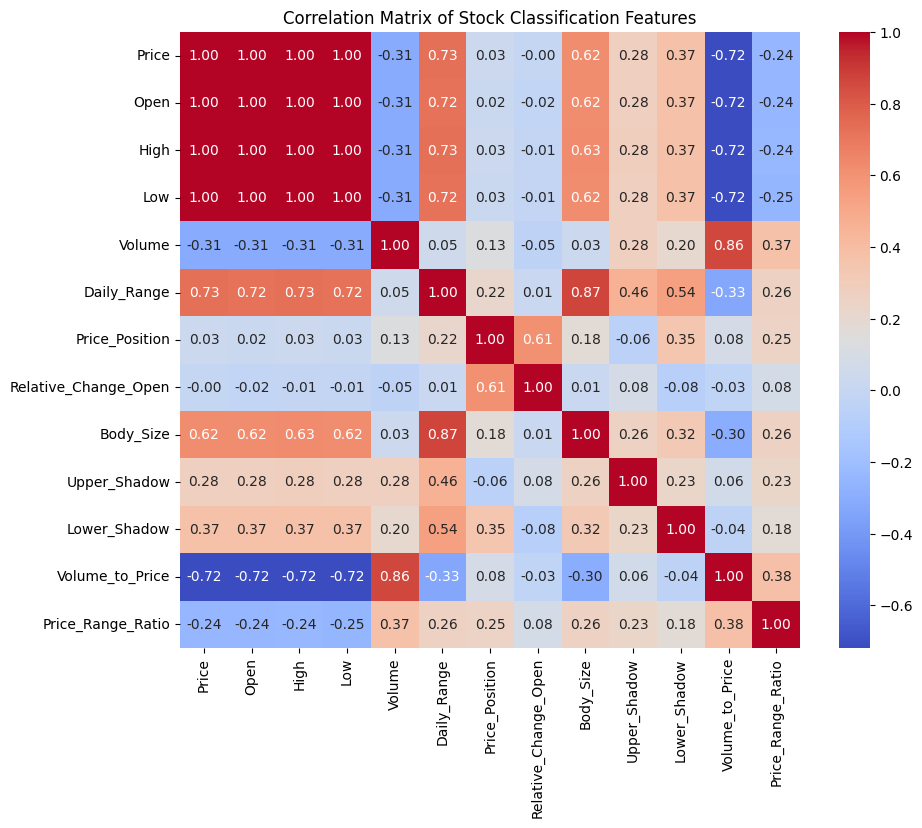

In [170]:
corr_matrix = x_train_processed.select_dtypes(include='number').corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Stock Classification Features')
plt.show()

<p>
A Pearson correlation matrix was computed to assess the linear relationships between numerical features. 
As shown, <code>Price</code>, <code>Open</code>, <code>High</code>, and <code>Low</code> exhibit extremely high pairwise correlations (1.00), indicating <strong>strong multicollinearity</strong> and feature redundancy.
</p>

<p>
To mitigate this issue and reduce dimensionality without losing valuable information, only one of these highly correlated features is retained. <code>Price</code> is selected to remain, while <code>Open</code>, <code>High</code>, and <code>Low</code> are dropped from the input features.
</p>

<p>
Removing these features helps prevent instability in models that are sensitive to multicollinearity, and improves interpretability and training efficiency.
</p>


In [171]:
x_train_processed.drop(['Open', 'High', 'Low'], axis=1, inplace=True)
x_test_processed.drop(['Open', 'High', 'Low'], axis=1, inplace=True)

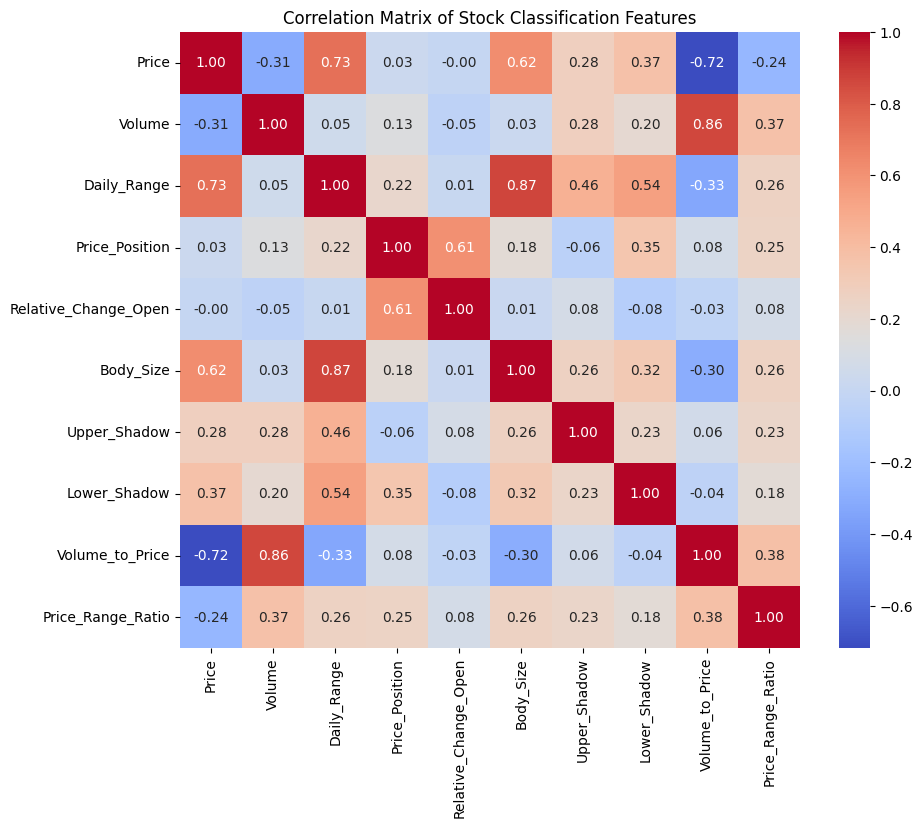

In [172]:
corr_matrix = x_train_processed.select_dtypes(include='number').corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Stock Classification Features')
plt.show()

<h4>7.2 Feature Distributions</h4>
<p>
Analyzing the distribution of each feature provides insight into potential irregularities such as skewness, heavy tails, or outliers, which may influence model performance or bias learning outcomes. Visual inspection also helps determine whether transformation or scaling has been effective.
</p>

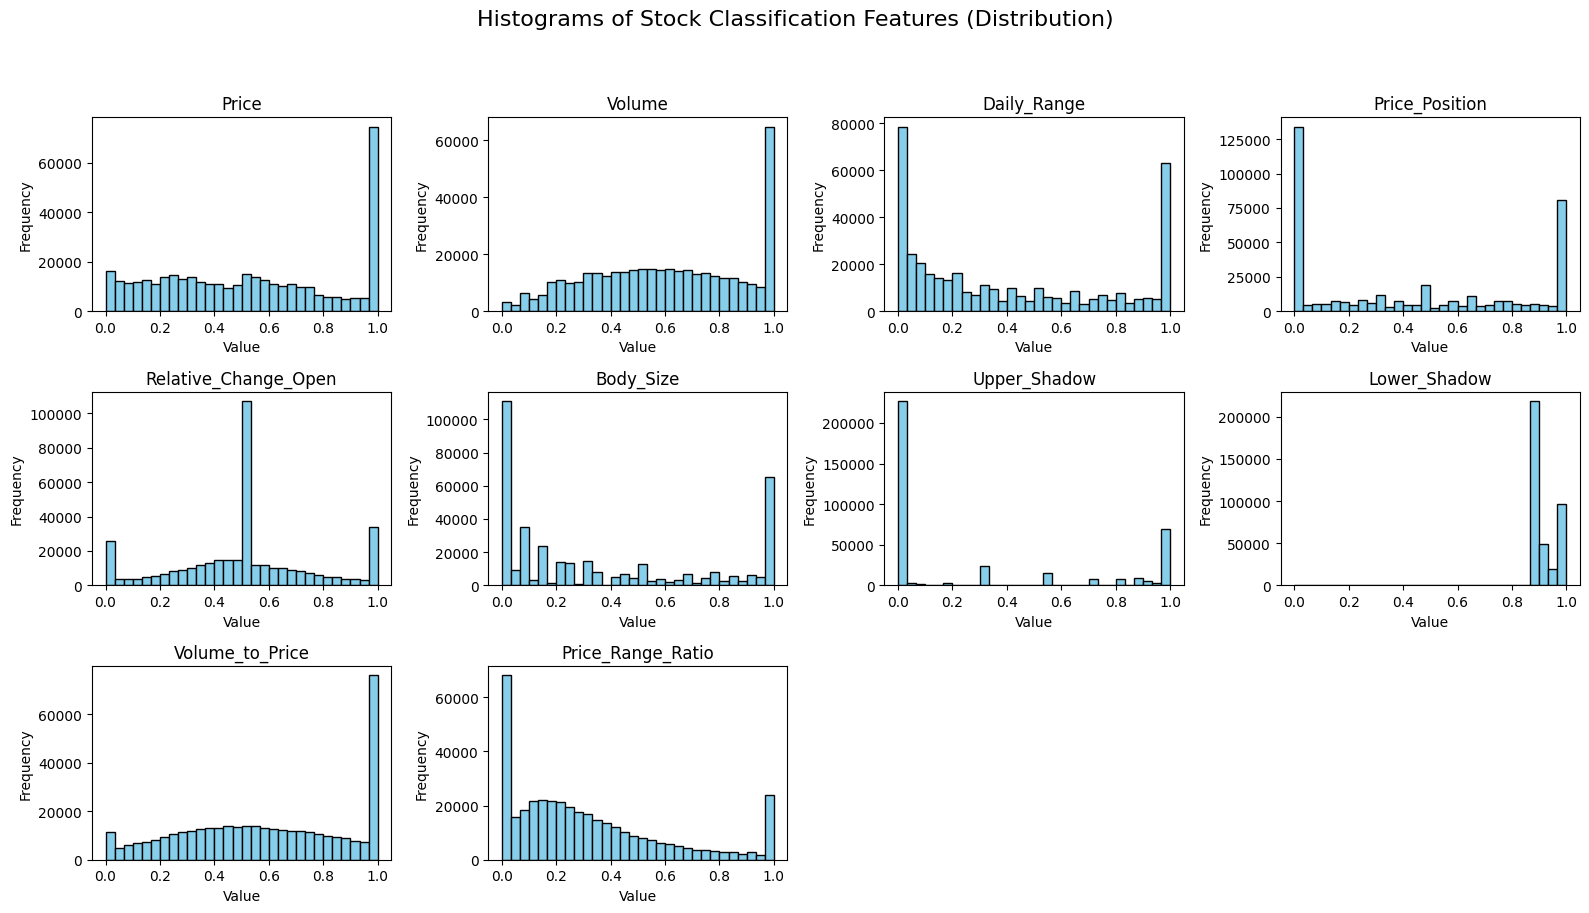

In [173]:
columns = x_train_processed.columns

fig, axes = plt.subplots(rows, cols, figsize=(16, 12))
axes = axes.flatten()

for i, column in enumerate(columns):
    axes[i].hist(x_train_processed[column], bins=30, edgecolor='black', color='skyblue')
    axes[i].set_title(column)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

for j in range(len(columns), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Histograms of Stock Classification Features (Distribution)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

<p>
The figures display histograms for ten engineered and original features from our non-temporal stock classification pipeline, showing the distribution of their values after preprocessing. Most features have been normalized to the range <code>0.0</code> to <code>1.0</code>, and several exhibit clear signs of <strong>capping</strong>—a technique used to limit extreme outlier values and improve model stability.
</p>

<strong>Overall Observations</strong>
<p>
Several features demonstrate characteristic capping behavior with prominent spikes at the boundary values. Features such as <code>Price</code>, <code>Volume</code>, <code>Price_Position</code>, and <code>Volume_to_Price</code> show extremely tall bars at <code>1.0</code>, indicating that high-value outliers were successfully clipped during preprocessing. This boundary accumulation confirms effective outlier management in the feature engineering pipeline.
</p>

<p>
The capping strategy appears particularly aggressive for certain market indicators, suggesting these features originally contained significant outliers that could have negatively impacted model performance if left unconstrained.
</p>


<h3>7.3 Descriptive Statistics</h3>

In [174]:
x_train_processed.select_dtypes(include='number').describe().T

,count,mean,std,min,25%,50%,75%,max
Price,385292.0,0.532463,0.326529,0.0,0.249310,0.518554,0.831022,1.0
Volume,385292.0,0.610173,0.279513,0.0,0.387368,0.612960,0.856337,1.0
Daily_Range,385292.0,0.400386,0.374662,0.0,0.037539,0.285714,0.760259,1.0
Price_Position,385292.0,0.426233,0.402365,0.0,0.000000,0.334559,0.852941,1.0
Relative_Change_Open,385292.0,0.505564,0.255637,0.0,0.375000,0.504914,0.625000,1.0
Body_Size,385292.0,0.370521,0.384079,0.0,0.000000,0.201540,0.756175,1.0
Upper_Shadow,385292.0,0.306910,0.414830,0.0,0.000000,0.000000,0.758721,1.0
Lower_Shadow,385292.0,0.913815,0.051132,0.0,0.874090,0.874090,0.970279,1.0
Volume_to_Price,385292.0,0.594914,0.302962,0.0,0.354525,0.593292,0.880262,1.0
Price_Range_Ratio,385292.0,0.313193,0.286417,0.0,0.089539,0.239631,0.453724,1.0


<h2>Section VIII. Initial Model Training - Classification Models</h2>

<h3>8.1 Linear Regression</h3>
<p>
Linear Regression was used as a baseline model due to its simplicity and ease of interpretation. As a basic method, it provides an initial performance benchmark. It also reveals whether a linear relationship exists between the features and the target variable, serving as a useful diagnostic before applying more complex models.
</p>

<h4>Build and Train</h4>

In [175]:
lr_model = LinearRegression()
lr_model.fit(x_train_processed, y_train)

LinearRegression()

<h4>Predict and Evaluate</h4>

In [176]:
y_pred = lr_model.predict(x_test_processed)

lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
lr_mae = mean_absolute_error(y_test, y_pred)
print(f"Linear Regression RMSE: {lr_rmse:.4f}")
print(f"Linear Regression MAE: {lr_mae:.4f}")

Linear Regression RMSE: 2.0418
Linear Regression MAE: 1.4768


<p>
The Linear Regression model achieved a <strong>Root Mean Squared Error (RMSE)</strong> of <code>2.0418</code>, a <strong>Mean Absolute Error (MAE)</strong> of <code>1.4768</code>, on the test set.
</p>

<p>
An <code>MAE</code> of around <code>2%</code> indicates that the model’s predictions deviate from actual changes by a moderate amount on average, while the higher <code>RMSE</code> suggests that larger errors occasionally occur. 
</p>

<p>
This result highlights the limitations of Linear Regression in modeling stock price changes, which are often influenced by complex, non-linear patterns. As a baseline, it establishes the lower bound of model performance and underscores the need for more robust regression techniques that can better capture the underlying dynamics of financial data.
</p>

<h3>8.2 Random Forest</h3>
<p>
This model was used to address the limitations of simpler methods like Linear Regression. Unlike linear models, Random Forest can capture non-linear relationships and complex interactions between features without requiring explicit transformation or manual feature engineering.
</p>

<p>
Its ability to reduce overfitting through averaging, while still learning from high-variance data, makes it well-suited for stock prediction tasks where patterns are often irregular and noisy. Random Forest was used as a stronger baseline to evaluate how well a non-linear, tree-based model can learn from non-temporal features.
</p>


<h4>Build and Train</h4>

In [177]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    bootstrap=True,
    oob_score=True,
    random_state=SEED
)


rf_model.fit(x_train_processed, y_train)

RandomForestRegressor(max_depth=8, max_features='sqrt', min_samples_leaf=5,
                      min_samples_split=10, n_estimators=200, oob_score=True,
                      random_state=42)

<h3>Predict and Evaluate</h3>

In [178]:
y_pred = rf_model.predict(x_test_processed)

rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rf_mae = mean_absolute_error(y_test, y_pred)
print(f"Random Forest RMSE: {rf_rmse:.4f}")
print(f"Random Forest MAE: {rf_mae:.4f}")

Random Forest RMSE: 2.0420
Random Forest MAE: 1.4771


<p>
The Random Forest model achieved a <strong>Root Mean Squared Error (RMSE)</strong> of <code>2.0420</code> and a <strong>Mean Absolute Error (MAE)</strong> of <code>1.4771</code> on the test set.
</p>

<p>
These values suggest that, on average, the model’s predictions deviate from actual next-day percentage changes by approximately 1.48%, with occasional larger errors pushing the RMSE slightly higher. The low error range indicates relatively stable and consistent performance after handling outliers in the target variable.
</p>

<p>
However, the Random Forest model's performance is not significantly different from that of Linear Regression, which produced similar RMSE and MAE values. This implies that, despite its greater complexity and capacity for modeling non-linear relationships, Random Forest did not extract substantially more predictive power from the available features. This may reflect the noisy, unpredictable nature of short-term stock changes or a lack of strong signals in the dataset.
</p>

<h3>8.3 XGBoost</h3>
<p>
XGBoost, or Extreme Gradient Boosting, is a scalable and efficient implementation of gradient-boosted decision trees. It is designed to build models sequentially, where each new tree corrects the errors of the previous ones. This approach often results in higher accuracy and better generalization compared to single-tree methods like Random Forest.
</p>

<p>
The model was included in this study due to its strong performance in structured data tasks and its proven success in regression problems involving noisy or complex relationships. XGBoost naturally handles non-linear patterns, supports regularization to prevent overfitting, and offers fast training through parallelization and optimized tree construction.
</p>

<p>
In the context of short-term stock price change prediction, XGBoost was selected to assess whether a more sophisticated ensemble method could outperform simpler baselines such as Linear Regression and Random Forest. Its ability to model complex feature interactions made it a suitable candidate for capturing subtle patterns in market behavior.
</p>

<h4>Build and Train</h4>

In [179]:
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    eval_metric='rmse',
    n_estimators=300,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=SEED
)

xgb_model.fit(x_train_processed, y_train,)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric='rmse', feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

<h4>Predict and Evaluate</h4>

In [180]:
y_pred = xgb_model.predict(x_test_processed)

xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
xgb_mae = mean_absolute_error(y_test, y_pred)
print(f"XGBoost RMSE: {xgb_rmse:.4f}")
print(f"XGBoost MAE: {xgb_mae:.4f}")

XGBoost RMSE: 2.0444
XGBoost MAE: 1.4832


<p>
The XGBoost model produced a <strong>Root Mean Squared Error (RMSE)</strong> of <code>2.0444</code> and a <strong>Mean Absolute Error (MAE)</strong> of <code>1.4832</code> on the test set.
</p>

<p>
These values indicate that the model's average deviation from the true next-day stock change was approximately <code>1.48%</code>, with occasional larger errors reflected in the slightly higher RMSE. The overall error magnitude is consistent with the other models in this pipeline.
</p>

<p>
Despite XGBoost's capacity to capture non-linear relationships and feature interactions, the model did not outperform Linear Regression or Random Forest. This outcome suggests that the available features did not provide strong enough signals for more complex models to leverage, likely due to the absence of temporal or trend-based information in the dataset.
</p>


<h3>8.4 Model Performance Comparison</h3>

<h4>Root Mean Squared Error (RMSE) Comparison</h4>

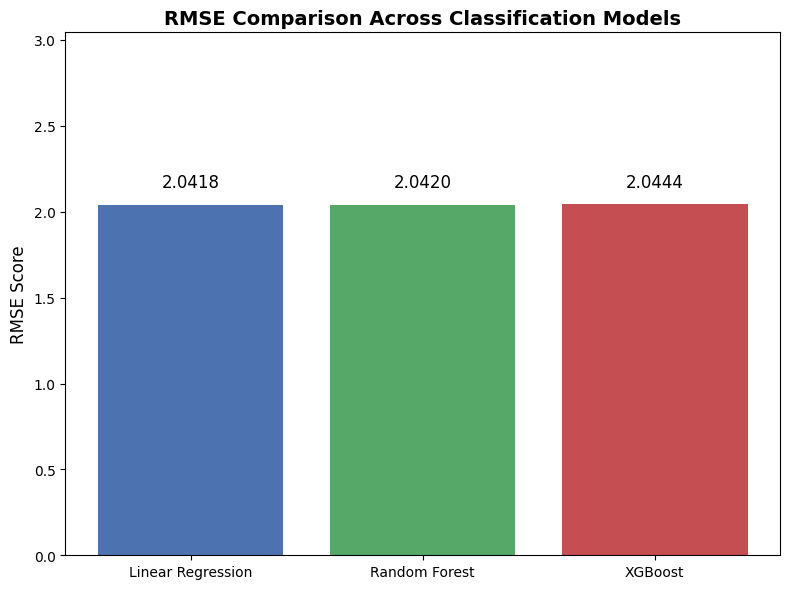

In [181]:
models = ['Linear Regression', 'Random Forest', 'XGBoost']
rmse_scores = [lr_rmse, rf_rmse, xgb_rmse]
colors = ['#4C72B0', '#55A868', '#C44E52']

plt.figure(figsize=(8, 6))
bars = plt.bar(models, rmse_scores, color=colors)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.1,
             f'{height:.4f}', ha='center', fontsize=12)

plt.title('RMSE Comparison Across Classification Models', fontsize=14, weight='bold')
plt.ylabel('RMSE Score', fontsize=12)
plt.ylim(0, max(rmse_scores) + 1)
plt.tight_layout()
plt.show()


<p>
The graph above illustrates the <strong>Root Mean Squared Error (RMSE)</strong> scores for the three regression models evaluated in the non-temporal pipeline. All models achieved very similar performance, with <code>Linear Regression</code> recording an RMSE of <code>2.0418</code>, <code>Random Forest</code> at <code>2.0420</code>, and <code>XGBoost</code> at <code>2.0444</code>.
</p>

<p>
The minimal difference in RMSE values indicates that none of the models was able to significantly outperform the others in predicting next-day stock price changes using only current-day features. This suggests that the added complexity of ensemble methods did not translate into a tangible performance gain, highlighting the limitations of non-temporal, row-based features in capturing predictive patterns within financial data.
</p>


<h4>Mean Absolute Error (MAE) Comparison</h4>

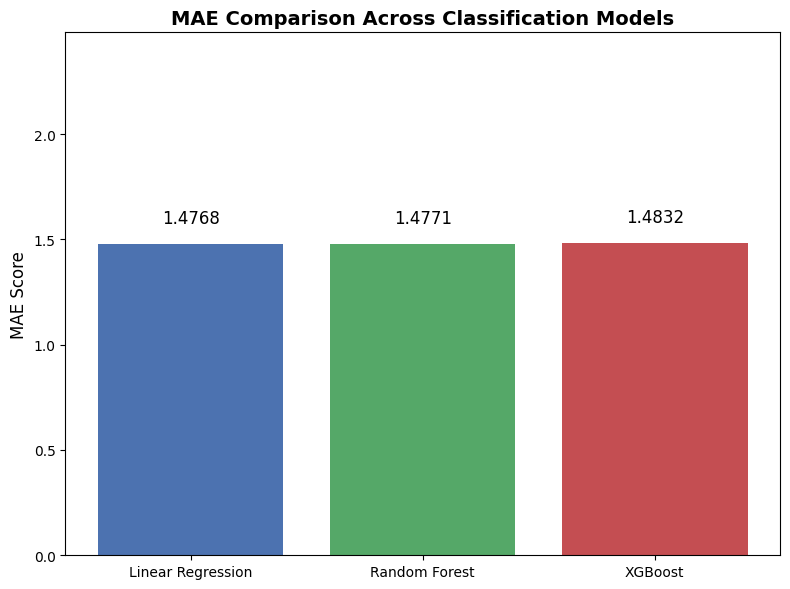

In [182]:
models = ['Linear Regression', 'Random Forest', 'XGBoost']
mae_scores = [lr_mae, rf_mae, xgb_mae]
colors = ['#4C72B0', '#55A868', '#C44E52']

plt.figure(figsize=(8, 6))
bars = plt.bar(models, mae_scores, color=colors)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.1,
             f'{height:.4f}', ha='center', fontsize=12)

plt.title('MAE Comparison Across Classification Models', fontsize=14, weight='bold')
plt.ylabel('MAE Score', fontsize=12)
plt.ylim(0, max(mae_scores) + 1)
plt.tight_layout()
plt.show()

<p>
The graph above presents a comparison of <strong>Mean Absolute Error (MAE)</strong> values for the three regression models tested. <code>Linear Regression</code> achieved the lowest MAE at <code>1.4768</code>, closely followed by <code>Random Forest</code> with <code>1.4771</code>, and <code>XGBoost</code> with <code>1.4832</code>.
</p>

<p>
The results reflect a consistent pattern across all models, with only marginal differences in average error. This further reinforces the observation that the current feature set does not offer a strong predictive signal for next-day stock price changes. Even models with more advanced learning capabilities, such as Random Forest and XGBoost, were unable to reduce the error significantly beyond what a simple linear model achieved.
</p>


<h3>8.5 Summary of Results</h3>

<table>
  <thead>
    <tr>
      <th>Model</th>
      <th>RMSE</th>
      <th>MAE</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td><strong>Linear Regression</strong></td>
      <td>2.0418</td>
      <td>1.4768</td>
    </tr>
    <tr>
      <td><strong>Random Forest</strong></td>
      <td>2.0420</td>
      <td>1.4771</td>
    </tr>
    <tr>
      <td><strong>XGBoost</strong></td>
      <td>2.0444</td>
      <td>1.4832</td>
    </tr>
  </tbody>
</table>

<p>
<code>Linear Regression</code> achieved the lowest error values overall, with an RMSE of <code>2.0418</code> and an MAE of <code>1.4768</code>. Both <code>Random Forest</code> and <code>XGBoost</code>, despite being more complex models capable of capturing non-linear patterns, did not significantly outperform the linear baseline. In fact, their error margins are nearly identical to that of Linear Regression, differing by less than <code>0.005</code> in both RMSE and MAE.
</p>

<p>
These findings suggest that the current feature set does not provide a strong predictive signal for next-day stock changes. The limited performance difference across models indicates that added model complexity does not yield substantial benefits under the constraints of non-temporal, snapshot-based features. This highlights the importance of incorporating richer temporal or trend-based information in future modeling efforts.
</p>

<h2>IX. Conclusion</h2>

<p>
This study evaluated two separate pipelines for predicting stock price changes: a <strong>non-temporal pipeline</strong> using same-day features, and a <strong>temporal forecasting pipeline</strong> incorporating past data through models such as LSTM, Prophet, and XGBoost Forecasting.
</p>

<p>
In the non-temporal pipeline, all three regression models—<code>Linear Regression</code>, <code>Random Forest</code>, and <code>XGBoost</code>—produced nearly indistinguishable results. The <strong>RMSE</strong> values ranged narrowly from <code>2.0418</code> to <code>2.0444</code>, while <strong>MAE</strong> values hovered between <code>1.4768</code> and <code>1.4832</code>. This marginal difference indicates that the added complexity of ensemble and boosting methods offered no measurable performance gain over a simple linear model.
</p>

<p>
This uniformity can be traced back to a limitation in feature design. The non-temporal pipeline relied solely on same-day engineered features, without any historical or trend-based context. As a result, the models lacked access to crucial temporal dynamics that typically influence stock behavior. In the absence of such information, even the most powerful algorithms defaulted to baseline-like predictions.
</p>

<p>
The temporal forecasting pipeline, on the other hand, yielded stronger results across the board. The <code>XGBoost Forecast</code> model achieved the best performance with an <strong>RMSE</strong> of <code>1.8148</code>, <strong>MAE</strong> of <code>1.3306</code>, and a <strong>Directional Accuracy</strong> of <code>62.11%</code>. The <code>LSTM</code> model followed closely, and even <code>Prophet</code>—a trend-based rule-driven model—outperformed the non-temporal models.
</p>

<p>
However, even the best temporal models demonstrated directional accuracies only in the <strong>60% range</strong>. This reinforces a broader truth: <strong>stock forecasting is inherently difficult</strong>. Prices are influenced not just by past trends but by countless unpredictable factors—economic reports, political news, investor sentiment, and global events—none of which are reflected in historical price data alone. While machine learning models can learn patterns, they cannot account for random shocks or market irrationality, which are common in financial markets.
</p>

<p>
The limited performance observed—particularly in the non-temporal pipeline—is not the result of flawed implementation or poor modeling choices. Instead, it highlights the <strong>fundamental challenge of using historical data to predict inherently forward-looking, reactive systems</strong>. Even well-tuned models face natural limits when attempting to forecast short-term market behavior using structured past data alone.
</p>


<h1 style="text-align: center;">End of Project</h1>